In [5]:
# Final Step처리하는 코드
# Final Step 1 : STXT에서 SPT 추출하는 코드

import os
import pandas as pd
from datetime import datetime
import unicodedata

BASE_DIR = "/Users/sangindo/Desktop/1. SSLI/1. STXT"
COMPANY  = "삼성생명보험"
OUTPUT = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx"

def normalize_text(text: str) -> str:
    """맥OS NFD → NFC 정규화"""
    if text is None:
        return ""
    return unicodedata.normalize("NFC", text)

def scan_products(base_dir: str, company_name: str):
    rows = []
    base_dir = os.path.abspath(base_dir)
    for root, _, files in os.walk(base_dir):
        rel = os.path.relpath(root, base_dir)
        product = None if rel == "." else rel.split(os.sep)[0]

        for fn in files:
            if fn.lower().endswith(".txt"):
                rider = os.path.splitext(fn)[0]
                rows.append({
                    "보험회사명": company_name,
                    "상품명": normalize_text(product or ""),
                    "특약명": normalize_text(rider),
                })
    return pd.DataFrame(rows, columns=["보험회사명","상품명","특약명"])

df = scan_products(BASE_DIR, COMPANY)
df.sort_values(["상품명","특약명"], inplace=True, ignore_index=True)
df.drop_duplicates(subset=["보험회사명","상품명","특약명"], inplace=True, ignore_index=True)

os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)
df.to_excel(OUTPUT, index=False)
print(f"✅ 저장 완료: {OUTPUT}, 총 {len(df)}건")


✅ 저장 완료: /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx, 총 10453건


In [8]:
이 코드는 ITXT파일과 검토가 필요할때 사용

# Final Step 2 : STXT에 추출한 SPT의 특약명과 ITXT파일에서의 파일명을 비교하는 코드 

# 결과보기에서 확인할 점은 SPT 엑셀에는 있는데 ITXT에 없으면 안됨
# 엑셀 특약 수	1800
# ITXT 파일 수	1891
# 양쪽 모두 있음	1800
# 엑셀에만 있음	0 ---------> 이경우만 문제 됨
# ITXT에만 있음	91

import os
import pandas as pd
import unicodedata

# ===== 경로 설정 =====
PBMT_PATH = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_PBMT_FINAL.xlsx"  # 질문에 주신 PBMT 파일
ITXT_DIR  = "/Users/sangindo/Desktop/1. SSLI/2. ITXT"
OUTPUT    = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_PBMT_ITXT_검증.xlsx"

def normalize(text: str) -> str:
    """macOS 파일명 안전: NFD→NFC 정규화 + 좌우공백 제거"""
    if text is None:
        return ""
    return unicodedata.normalize("NFC", str(text)).strip()

# --- 1) PBMT 엑셀에서 '파일명' 컬럼 로드 (항상 첫 번째 시트) ---
df_pbmt = pd.read_excel(PBMT_PATH, sheet_name=0)
if "파일명" not in df_pbmt.columns:
    raise KeyError("엑셀에 '파일명' 컬럼이 없습니다. 컬럼명을 확인하세요.")

# 정규화
df_pbmt["파일명"] = df_pbmt["파일명"].apply(normalize)

# 파일명 집합 (확장자 포함: 예) '무배당암진단특약.txt')
excel_files = set(df_pbmt["파일명"].tolist())

# --- 2) ITXT 폴더에서 실제 .txt 파일명 수집 (재귀 스캔, 확장자 포함) ---
itxt_files = set()
for root, _, files in os.walk(ITXT_DIR):
    for fn in files:
        if fn.lower().endswith(".txt"):
            itxt_files.add(normalize(fn))

# --- 3) 비교 ---
missing_in_itxt = sorted(excel_files - itxt_files)  # 엑셀에는 있는데 ITXT에 없는 파일명
extra_in_itxt   = sorted(itxt_files - excel_files)  # ITXT에는 있는데 엑셀에 없는 파일명
common          = sorted(excel_files & itxt_files)  # 양쪽 모두 존재

# (선택) 파일명 <-> 특약명 일관성도 함께 체크(파일명에서 .txt 제거 후 비교)
mismatch_name_rows = []
if "특약명" in df_pbmt.columns:
    for _, row in df_pbmt.iterrows():
        f = normalize(row["파일명"])
        r = normalize(row["특약명"])
        base = os.path.splitext(f)[0]  # .txt 제거
        if base != r:
            mismatch_name_rows.append({"파일명": f, "특약명": r, "비고": "파일명(.txt제외) ≠ 특약명"})
df_mismatch = pd.DataFrame(mismatch_name_rows)

# --- 4) 요약/상세 테이블 구성 ---
summary = pd.DataFrame([
    {"구분": "PBMT 파일명 수", "값": len(excel_files)},
    {"구분": "ITXT 파일명 수", "값": len(itxt_files)},
    {"구분": "양쪽 모두 있음", "값": len(common)},
    {"구분": "엑셀에만 있음", "값": len(missing_in_itxt)},
    {"구분": "ITXT에만 있음", "값": len(extra_in_itxt)},
    {"구분": "파일명(.txt제외)≠특약명 행 수", "값": len(df_mismatch)},
])

df_missing = pd.DataFrame(missing_in_itxt, columns=["엑셀_only(ITXT에 없음)"])
df_extra   = pd.DataFrame(extra_in_itxt,   columns=["ITXT_only(엑셀에 없음)"])
df_common  = pd.DataFrame(common,          columns=["공통 파일명"])

# --- 5) 엑셀 저장 ---
os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)
with pd.ExcelWriter(OUTPUT, engine="openpyxl") as w:
    summary.to_excel(w, index=False, sheet_name="검증_요약")
    if len(df_missing): df_missing.to_excel(w, index=False, sheet_name="엑셀_only")
    if len(df_extra):   df_extra.to_excel(w, index=False, sheet_name="ITXT_only")
    if len(df_common):  df_common.to_excel(w, index=False, sheet_name="공통")
    if len(df_mismatch): df_mismatch.to_excel(w, index=False, sheet_name="파일명_특약명_불일치")

# --- 6) 콘솔 출력 ---
print(f"✅ 검증 완료: {OUTPUT}")
print(f" - PBMT 파일명 수: {len(excel_files)}")
print(f" - ITXT 파일명 수: {len(itxt_files)}")
print(f" - 양쪽 모두 있음: {len(common)}")
print(f" - 엑셀에만 있음: {len(missing_in_itxt)}")
print(f" - ITXT에만 있음: {len(extra_in_itxt)}")
print(f" - 파일명(.txt제외)≠특약명: {len(df_mismatch)}")

# 요청하신 성공 메시지 규칙 적용
if len(missing_in_itxt) == 0:
    print("🎉 SPT에 필요한 모든 파일이 있음 : 정상")  # 통일된 문구 사용


✅ 검증 완료: /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_PBMT_ITXT_검증.xlsx
 - PBMT 파일명 수: 1942
 - ITXT 파일명 수: 1891
 - 양쪽 모두 있음: 1829
 - 엑셀에만 있음: 113
 - ITXT에만 있음: 62
 - 파일명(.txt제외)≠특약명: 1344


In [9]:
# Final Step 3 : SPT파일과 PBMT파일을 매칭하는 코드

# 결과보기에서 확인할 점은 SPT 엑셀에는 있는데 ITXT에 없으면 안됨
# 엑셀 특약 수	1800

import os
import pandas as pd
import unicodedata

# ===== 경로 설정 =====
SPT_PATH     = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx"
PBMT_PATH    = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_PBMT_FINAL.xlsx"
VALIDATION_XLSX = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_PBMT_VAL.xlsx"   # 검증파일
BMT_XLSX        = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_BMT_FINAL.xlsx"    # BMT파일

# ===== 유틸 =====
def norm(s: str) -> str:
    """macOS 한글 정규화(NFD→NFC) + 좌우 공백 제거"""
    if s is None:
        return ""
    return unicodedata.normalize("NFC", str(s)).strip()

def base_no_ext(filename: str) -> str:
    """확장자 제거(.txt 등)"""
    return os.path.splitext(norm(filename))[0]

# ===== 1) 데이터 로드(각 첫 번째 시트) & 헤더 정리 =====
df_spt  = pd.read_excel(SPT_PATH,  sheet_name=0)
df_pbmt = pd.read_excel(PBMT_PATH, sheet_name=0)
df_spt.columns  = [c.strip() for c in df_spt.columns]
df_pbmt.columns = [c.strip() for c in df_pbmt.columns]

# 필수 컬럼 검증
need_spt_cols  = {"보험회사명", "상품명", "특약명"}
need_pbmt_cols = {"파일명"}
miss_s = need_spt_cols - set(df_spt.columns)
miss_p = need_pbmt_cols - set(df_pbmt.columns)
if miss_s:
    raise KeyError(f"SPT 파일에 필수 컬럼이 없습니다: {miss_s}")
if miss_p:
    raise KeyError(f"PBMT 파일에 필수 컬럼이 없습니다: {miss_p}")

# 텍스트 정규화
for col in ["보험회사명", "상품명", "특약명"]:
    df_spt[col] = df_spt[col].apply(norm)
df_pbmt["파일명"]     = df_pbmt["파일명"].apply(norm)
df_pbmt["파일베이스"] = df_pbmt["파일명"].apply(base_no_ext)  # .txt 제거

# ===== 2) 매칭 (특약명 == 파일베이스) — many-to-many 조인 =====
merged = pd.merge(
    df_spt,
    df_pbmt,
    left_on="특약명",
    right_on="파일베이스",
    how="left",
    suffixes=("_SPT", "_PBMT")
)

# 충돌/명확화 컬럼 리네임
col_rename = {}
if "특약명_SPT" in merged.columns: col_rename["특약명_SPT"] = "특약명"
if "특약명_PBMT" in merged.columns: col_rename["특약명_PBMT"] = "PBMT_특약명"
if "파일명" in merged.columns:      col_rename["파일명"] = "PBMT_파일명"
if "파일베이스" in merged.columns:   col_rename["파일베이스"] = "PBMT_파일베이스"
merged.rename(columns=col_rename, inplace=True)

# PBMT 매칭 판정 컬럼
hit_col = "PBMT_파일명" if "PBMT_파일명" in merged.columns else "파일명"

# ===== 3) 검증 리포트 구성 =====
# 특약별 매칭개수(= PBMT 연결 행 수)
match_counts = (
    merged.assign(_hit=~merged[hit_col].isna())
          .groupby("특약명", as_index=False)["_hit"]
          .sum()
          .rename(columns={"_hit": "매칭개수(PBMT행수)"})
          .sort_values("매칭개수(PBMT행수)", ascending=False)
)

# 미매칭 SPT 목록
spt_unmatched = merged[merged[hit_col].isna()][["보험회사명","상품명","특약명"]].drop_duplicates()

summary = pd.DataFrame([
    {"지표": "SPT 특약 수(고유)",        "값": int(df_spt["특약명"].nunique())},
    {"지표": "PBMT 파일베이스 수(고유)",  "값": int(df_pbmt["파일베이스"].nunique())},
    {"지표": "매칭된 특약 수(>0)",        "값": int((match_counts["매칭개수(PBMT행수)"]>0).sum())},
    {"지표": "미매칭 특약 수(=0)",        "값": int((match_counts["매칭개수(PBMT행수)"]==0).sum())},
    {"지표": "다중 매칭 특약 수(>1)",      "값": int((match_counts["매칭개수(PBMT행수)"]>1).sum())},
])

# ===== 4) 검증파일 저장 =====
os.makedirs(os.path.dirname(VALIDATION_XLSX), exist_ok=True)
with pd.ExcelWriter(VALIDATION_XLSX, engine="openpyxl") as w:
    merged.to_excel(w, index=False, sheet_name="MATCH")
    spt_unmatched.to_excel(w, index=False, sheet_name="SPT_미매칭")
    match_counts.to_excel(w, index=False, sheet_name="특약별_매칭개수")
    summary.to_excel(w, index=False, sheet_name="검증_요약")

print(f"✅ 검증파일 저장: {VALIDATION_XLSX}")
print(f" - 미매칭 특약 수: {int((match_counts['매칭개수(PBMT행수)']==0).sum())}")
print(f" - 다중 매칭 특약 수: {int((match_counts['매칭개수(PBMT행수)']>1).sum())}")

# ===== 5) BMT 파일 생성 (매칭된 행만) + 완전중복 검사 =====
# 유지 컬럼
keep_cols = ["보험회사명", "상품명", "특약명", "급부명", "지급기준", "지급내용", "기타사항", "대상"]
keep_cols = [c for c in keep_cols if c in merged.columns]

# 매칭된 행만
df_matched_only = merged[merged[hit_col].notna()].copy()

# (선택) 급부명 비어있는 행 제외하려면 주석 해제
# if "급부명" in df_matched_only.columns:
#     df_matched_only = df_matched_only[df_matched_only["급부명"].notna() & (df_matched_only["급부명"].astype(str).str.strip()!="")]

df_bmt = df_matched_only[keep_cols].copy()

# 보기 좋은 정렬
sort_cols = [c for c in ["보험회사명", "상품명", "특약명", "급부명"] if c in df_bmt.columns]
if sort_cols:
    df_bmt.sort_values(sort_cols, inplace=True, ignore_index=True)

# 완전중복(모든 열 동일) 탐지
full_dup_mask = df_bmt.duplicated(keep=False)
df_bmt_dups   = df_bmt[full_dup_mask].copy()
n_full_dup    = int(len(df_bmt_dups))

# 완전중복 제거본(첫 행만 유지)
df_bmt_dedup_all = df_bmt.drop_duplicates(keep="first").copy()

# 요약
bmt_summary = pd.DataFrame([
    {"지표": "BMT 총 행 수(매칭행)", "값": int(len(df_bmt))},
    {"지표": "완전중복 행 수",       "값": n_full_dup},
    {"지표": "중복 제거 후 행 수",    "값": int(len(df_bmt_dedup_all))},
])

# 저장
os.makedirs(os.path.dirname(BMT_XLSX), exist_ok=True)
with pd.ExcelWriter(BMT_XLSX, engine="openpyxl") as w:
    df_bmt.to_excel(w, index=False, sheet_name="BMT")                        # 원본(매칭행)
    bmt_summary.to_excel(w, index=False, sheet_name="BMT_요약")              # 요약
    if n_full_dup > 0:
        df_bmt_dups.to_excel(w, index=False, sheet_name="BMT_완전중복행")    # 완전중복 리포트
    df_bmt_dedup_all.to_excel(w, index=False, sheet_name="BMT_중복제거")     # 완전중복 제거본

print(f"✅ BMT파일 저장: {BMT_XLSX}")
print(f" - BMT 총 행 수: {int(len(df_bmt))}")
print(f" - 완전중복 행 수: {n_full_dup}")
print(f" - 중복 제거 후 행 수: {int(len(df_bmt_dedup_all))}")

# 전체 매칭 상태 메시지
if (match_counts["매칭개수(PBMT행수)"] >= 1).all():
    print("🎉 모든 SPT 특약명이 PBMT 파일명(.txt 제거)과 매칭됨 : 정상")
else:
    print("⚠️ 일부 SPT 특약이 PBMT에서 매칭되지 않았습니다. 검증파일의 'SPT_미매칭' 시트를 확인하세요.")


✅ 검증파일 저장: /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_PBMT_VAL.xlsx
 - 미매칭 특약 수: 55
 - 다중 매칭 특약 수: 1191
✅ BMT파일 저장: /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_BMT_FINAL.xlsx
 - BMT 총 행 수: 15084
 - 완전중복 행 수: 20
 - 중복 제거 후 행 수: 15067
⚠️ 일부 SPT 특약이 PBMT에서 매칭되지 않았습니다. 검증파일의 'SPT_미매칭' 시트를 확인하세요.


In [10]:
# Final Step 4 : SPT파일과 PCMT파일 및 PCMT_LSIT파일을 병합해 최종CMT파일 추출 코드

import os
import pandas as pd
import unicodedata

# ===== 경로 설정 (필요시 수정) =====
BASE_DIR = "/Users/sangindo/Desktop/1. SSLI/12.FINAL"
SPT_PATH        = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx" # SPT (회사명/상품명/특약명)
PCMT_LIST_PATH  = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_PCMT_LIST.xlsx" # PCMT LIST (원본파일명/분류표명/생성여부 등)
PCMT_FINAL_PATH = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_PCMT_FINAL.xlsx" # PCMT FINAL (파일명/분류표명/분류코드/처리상태)
CMT_OUTPUT_PATH = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_CMT_FINAL.xlsx"  # 결과 CMT


def nfc(s):
    return "" if s is None else unicodedata.normalize("NFC", str(s)).strip()

# ===== 1) 로드 & 정규화 =====
df_spt  = pd.read_excel(SPT_PATH,        sheet_name=0)
df_plst = pd.read_excel(PCMT_LIST_PATH,  sheet_name=0)
df_pfin = pd.read_excel(PCMT_FINAL_PATH, sheet_name=0)

df_spt.columns  = [nfc(c) for c in df_spt.columns]
df_plst.columns = [nfc(c) for c in df_plst.columns]
df_pfin.columns = [nfc(c) for c in df_pfin.columns]

# 필수 컬럼 체크
need_spt, need_plst, need_pfin = {"보험회사명","상품명","특약명"}, {"원본파일명","분류표명","생성여부"}, {"분류표명","분류코드","처리상태"}
for need, name, cols in [(need_spt,"SPT",df_spt.columns),(need_plst,"PCMT_LIST",df_plst.columns),(need_pfin,"PCMT_FINAL",df_pfin.columns)]:
    lack = need - set(cols)
    if lack: raise KeyError(f"{name} 필수 컬럼 없음: {lack}")

for c in ["보험회사명","상품명","특약명"]:
    df_spt[c] = df_spt[c].apply(nfc)
for c in ["원본파일명","저장된분류표명","분류표명","별표번호","생성여부","추출파일명","통합파일명","추출사유","저장상태","통합파일존재"]:
    if c in df_plst.columns: df_plst[c] = df_plst[c].apply(nfc)
for c in ["파일명","분류표명","분류코드","제외코드","처리상태"]:
    if c in df_pfin.columns: df_pfin[c] = df_pfin[c].apply(nfc)

# ===== 2) 기본 필터 =====
# LIST: 분류표명 非공백 & 생성여부 == 'S'
df_plst_f = df_plst[(df_plst["분류표명"].astype(str).str.strip() != "") & (df_plst["생성여부"] == "S")].copy()
# FINAL: 처리상태 == '정상완료' (없으면 전체 사용)
df_pfin_f = df_pfin[(df_pfin["처리상태"] == "정상완료") | (df_pfin["처리상태"].isna())].copy()

# ===== 3) 조인 =====
# SPT(특약명) ↔ LIST(원본파일명)
s1 = pd.merge(
    df_spt[["보험회사명","상품명","특약명"]].drop_duplicates(),
    df_plst_f[["원본파일명","분류표명"]].drop_duplicates(),
    left_on="특약명", right_on="원본파일명", how="left"
)
# s1: [보험회사명, 상품명, 특약명, 원본파일명, 분류표명]

# LIST(분류표명) ↔ FINAL(분류표명→분류코드)
s2 = pd.merge(
    s1,
    df_pfin_f[["분류표명","분류코드"]].drop_duplicates(),
    on="분류표명",
    how="left"
)
# s2: [보험회사명, 상품명, 특약명, 원본파일명, 분류표명, 분류코드]

# ===== 4) CMT 구성 (빈값 행 제거 + 중복 제거 + 정렬) =====
df_cmt = s2[["보험회사명","상품명","분류표명","분류코드"]].copy()
for col in df_cmt.columns:
    df_cmt[col] = df_cmt[col].apply(nfc)

# 분류표명/분류코드 비어있는 행 제거
df_cmt.replace({"분류표명": {"nan": ""}, "분류코드": {"nan": ""}}, inplace=True)
before_rows = len(df_cmt)
df_cmt = df_cmt.dropna(subset=["분류표명","분류코드"])
df_cmt = df_cmt[(df_cmt["분류표명"].str.strip() != "") & (df_cmt["분류코드"].str.strip() != "")]
after_filter_rows = len(df_cmt)

# 완전중복 제거
df_cmt.drop_duplicates(keep="first", inplace=True, ignore_index=True)
after_dedup_rows = len(df_cmt)

# 정렬
sort_cols = [c for c in ["보험회사명","상품명","분류표명"] if c in df_cmt.columns]
if sort_cols:
    df_cmt.sort_values(sort_cols, inplace=True, ignore_index=True)

# ===== 5) 미매칭 리포트 =====
# SPT→LIST 미매칭: 분류표명 없음
unmatched_list  = s1[s1["분류표명"].isna()][["보험회사명","상품명","특약명"]].drop_duplicates()
# LIST→FINAL 미매칭: 분류표명은 있으나 분류코드 없음
unmatched_final = s2[s2["분류코드"].isna() & s2["분류표명"].notna()][["분류표명"]].drop_duplicates()

# ===== 6) 상품별 분류표 매칭 집계 (CMT 기준) =====
# (회사,상품,분류표명) 고유화 후 집계
pairs = df_cmt.drop_duplicates(subset=["보험회사명","상품명","분류표명"]).copy()

by_product = (
    pairs.groupby(["보험회사명","상품명"], as_index=False)["분류표명"]
         .nunique()
         .rename(columns={"분류표명":"분류표_개수"})
         .sort_values(["보험회사명","분류표_개수","상품명"], ascending=[True, False, True])
)

distribution = (
    by_product["분류표_개수"]
    .value_counts(dropna=False)
    .rename_axis("분류표_개수")
    .reset_index(name="상품_개수")
    .sort_values("분류표_개수")
)

total_products = by_product.shape[0]
total_mappings = pairs.shape[0]
avg_tables = round(float(by_product["분류표_개수"].mean()), 2) if total_products > 0 else 0
max_tables = int(by_product["분류표_개수"].max()) if total_products > 0 else 0

summary_main = pd.DataFrame([
    {"지표":"CMT 행 수(필터 전)",               "값": int(before_rows)},
    {"지표":"CMT 행 수(빈값 제거 후)",           "값": int(after_filter_rows)},
    {"지표":"CMT 행 수(중복 제거 후)",           "값": int(after_dedup_rows)},
    {"지표":"상품 수(회사·상품 고유)",           "값": int(total_products)},
    {"지표":"분류표 매핑 수(회사·상품·분류표명)", "값": int(total_mappings)},
    {"지표":"상품당 평균 분류표 수",              "값": avg_tables},
    {"지표":"상품당 최대 분류표 수",              "값": max_tables},
    {"지표":"SPT→LIST 미매칭 수",               "값": int(len(unmatched_list))},
    {"지표":"LIST→FINAL 미매칭 수",             "값": int(len(unmatched_final))},
])

# ===== 7) 저장 (한 번에 모든 시트 작성) =====
os.makedirs(os.path.dirname(CMT_OUTPUT_PATH), exist_ok=True)
with pd.ExcelWriter(CMT_OUTPUT_PATH, engine="openpyxl") as w:
    # 최종 산출
    df_cmt.to_excel(w, index=False, sheet_name="CMT")
    # 요약/검증
    summary_main.to_excel(w, index=False, sheet_name="CMT_요약")
    if len(unmatched_list) > 0:
        unmatched_list.to_excel(w, index=False, sheet_name="미매칭_SPT_to_LIST")
    if len(unmatched_final) > 0:
        unmatched_final.to_excel(w, index=False, sheet_name="미매칭_LIST_to_FINAL")
    # 상품별 집계/분포
    by_product.to_excel(w, index=False, sheet_name="CMT_상품별집계")
    distribution.to_excel(w, index=False, sheet_name="CMT_분류표수_분포")

# ===== 8) 콘솔 요약 =====
print(f"✅ CMT 생성 및 집계 완료: {CMT_OUTPUT_PATH}")
print(f" - 최종 CMT 행(빈값/중복 제거 후): {after_dedup_rows}")
print(f" - 상품 수(회사·상품 고유): {total_products}")
print(f" - 분류표 매핑 수(회사·상품·분류표명): {total_mappings}")
print(f" - 상품당 평균/최대 분류표 수: {avg_tables} / {max_tables}")
print(f" - 미매칭 SPT→LIST: {len(unmatched_list)}  |  LIST→FINAL: {len(unmatched_final)}")
print("\n[분포: 분류표 N개 ↔ 상품 개수]")
if len(distribution) == 0:
    print("  (데이터 없음)")
else:
    for _, r in distribution.iterrows():
        print(f"  · {int(r['분류표_개수'])}개 → {int(r['상품_개수'])}개 상품")


✅ CMT 생성 및 집계 완료: /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_CMT_FINAL.xlsx
 - 최종 CMT 행(빈값/중복 제거 후): 1773
 - 상품 수(회사·상품 고유): 101
 - 분류표 매핑 수(회사·상품·분류표명): 1773
 - 상품당 평균/최대 분류표 수: 17.55 / 61
 - 미매칭 SPT→LIST: 10352  |  LIST→FINAL: 2

[분포: 분류표 N개 ↔ 상품 개수]
  · 1개 → 7개 상품
  · 2개 → 9개 상품
  · 3개 → 4개 상품
  · 4개 → 4개 상품
  · 5개 → 1개 상품
  · 7개 → 2개 상품
  · 8개 → 2개 상품
  · 10개 → 6개 상품
  · 11개 → 5개 상품
  · 12개 → 1개 상품
  · 13개 → 2개 상품
  · 14개 → 4개 상품
  · 15개 → 10개 상품
  · 16개 → 2개 상품
  · 17개 → 2개 상품
  · 18개 → 1개 상품
  · 19개 → 3개 상품
  · 20개 → 2개 상품
  · 21개 → 4개 상품
  · 22개 → 2개 상품
  · 23개 → 1개 상품
  · 24개 → 1개 상품
  · 25개 → 1개 상품
  · 26개 → 1개 상품
  · 27개 → 1개 상품
  · 28개 → 2개 상품
  · 29개 → 2개 상품
  · 31개 → 1개 상품
  · 33개 → 2개 상품
  · 34개 → 3개 상품
  · 35개 → 2개 상품
  · 38개 → 2개 상품
  · 39개 → 2개 상품
  · 45개 → 1개 상품
  · 46개 → 1개 상품
  · 49개 → 1개 상품
  · 50개 → 2개 상품
  · 54개 → 1개 상품
  · 61개 → 1개 상품


In [14]:

# 생성된 엑셀파일의 품질검사

import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# 파일 경로 설정 (실제 파일 경로로 수정하세요)
bmt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_BMT_FINAL.xlsx"
cmt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_CMT_FINAL.xlsx" 
spt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx"

def check_excel_duplicates(file_path, sheet_name=None, file_label=""):
    """Excel 파일의 중복 행 검사"""
    print(f"\n=== {file_label} 파일 중복 검사 ===")
    
    # 파일 로드
    try:
        if sheet_name:
            df = pd.read_excel(file_path, sheet_name=sheet_name)
        else:
            df = pd.read_excel(file_path)
        print(f"총 {len(df):,}개 행 로드")
    except Exception as e:
        print(f"파일 로드 실패: {e}")
        return
    
    # 완전 중복 검사
    duplicated_mask = df.duplicated(keep=False)
    duplicate_rows = df[duplicated_mask]
    
    if len(duplicate_rows) == 0:
        print("✅ 완전 중복 행 없음")
        return
    
    print(f"⚠️ 총 {len(duplicate_rows)}개 중복 행 발견")
    
    # 중복 그룹별로 정리
    df_with_index = df.reset_index()
    df_with_index['original_row'] = df_with_index.index + 2  # Excel 행 번호 (헤더 포함)
    
    # 중복된 행들을 그룹으로 묶기
    duplicate_groups = df_with_index[duplicated_mask].groupby(
        df_with_index[duplicated_mask].drop(['original_row'], axis=1).apply(
            lambda x: '|'.join(x.astype(str)), axis=1
        )
    )
    
    print("\n중복 그룹 상세:")
    for i, (_, group) in enumerate(duplicate_groups, 1):
        row_numbers = group['original_row'].tolist()
        print(f"  그룹 {i}: 행 {row_numbers} ({len(row_numbers)}개 중복)")
        
        # 샘플 데이터 표시 (첫 3개 컬럼만)
        sample_data = group.iloc[0, 1:-1]  # index와 original_row 제외
        sample_cols = list(sample_data.index)[:3]
        sample_values = [str(sample_data[col])[:20] + "..." if len(str(sample_data[col])) > 20 
                        else str(sample_data[col]) for col in sample_cols]
        print(f"    샘플: {dict(zip(sample_cols, sample_values))}")
        
        if i >= 10:  # 상위 10개 그룹만 표시
            remaining = len(duplicate_groups) - 10
            if remaining > 0:
                print(f"    ... 외 {remaining}개 그룹 더 있음")
            break

def main():
    """메인 실행 함수"""
    print("📋 Excel 파일 중복 행 검사 시작")
    print("=" * 50)
    
    files = [
        (bmt_file, "BMT", "BMT"),
        (cmt_file, "CMT", "CMT"), 
        (spt_file, None, "SPT")
    ]
    
    for file_path, sheet_name, label in files:
        try:
            check_excel_duplicates(file_path, sheet_name, label)
            
        except FileNotFoundError:
            print(f"\n❌ {label} 파일을 찾을 수 없습니다: {file_path}")
        except Exception as e:
            print(f"\n❌ {label} 파일 처리 중 오류: {e}")
    
    print(f"\n{'='*50}")
    print("📊 검사 완료")

if __name__ == "__main__":
    main()




📋 Excel 파일 중복 행 검사 시작

=== BMT 파일 중복 검사 ===
총 15,084개 행 로드
⚠️ 총 20개 중복 행 발견

중복 그룹 상세:
  그룹 1: 행 [4503] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성산업재해보장보험(2209)(무배당...', '특약명': '삼성산업재해보장보험(2209)(무배당...'}
  그룹 2: 행 [4504] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성산업재해보장보험(2209)(무배당...', '특약명': '삼성산업재해보장보험(2209)(무배당...'}
  그룹 3: 행 [4879] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성생명New퍼펙트상해보험1.0(재가...', '특약명': 'New퍼펙트상해보험1.0(재가입형,무...'}
  그룹 4: 행 [4880] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성생명New퍼펙트상해보험1.0(재가...', '특약명': 'New퍼펙트상해보험1.0(재가입형,무...'}
  그룹 5: 행 [4881] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성생명New퍼펙트상해보험1.0(재가...', '특약명': 'New퍼펙트상해보험1.0(재가입형,무...'}
  그룹 6: 행 [4882] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성생명New퍼펙트상해보험1.0(재가...', '특약명': 'New퍼펙트상해보험1.0(재가입형,무...'}
  그룹 7: 행 [4883] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성생명New퍼펙트상해보험1.0(재가...', '특약명': 'New퍼펙트상해보험1.0(재가입형,무...'}
  그룹 8: 행 [4884] (1개 중복)
    샘플: {'보험회사명': '삼성생명보험', '상품명': '삼성생명N

In [17]:
# 품질검사 재저장 코드

import pandas as pd
import logging
import os

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# 파일 경로 설정
bmt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_BMT_FINAL.xlsx"
cmt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_CMT_FINAL.xlsx" 
spt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx"

# 저장할 위치 설정
output_directory = "/Users/sangindo/Desktop/1. SSLI/13.NORMAL/"

def check_excel_duplicates(file_path, sheet_name=None, file_label=""):
    """Excel 파일의 중복 행 검사 및 제거"""
    print(f"\n=== {file_label} 파일 중복 검사 ===")
    
    # 파일 로드
    try:
        if sheet_name:
            df = pd.read_excel(file_path, sheet_name=sheet_name)
        else:
            df = pd.read_excel(file_path)
        print(f"총 {len(df):,}개 행 로드")
    except Exception as e:
        print(f"파일 로드 실패: {e}")
        return
    
    # 중복 검사 - 제거될 행들 찾기
    duplicated_mask = df.duplicated(keep='first')  # 첫 번째는 유지, 나머지는 True
    duplicate_rows = df[duplicated_mask]
    
    if len(duplicate_rows) == 0:
        print("✅ 완전 중복 행 없음")
    else:
        print(f"⚠️ 총 {len(duplicate_rows)}개 중복 행 발견 (제거 예정)")
        
        # 제거될 행의 위치와 내용 표시
        print("\n🗑️ 제거될 중복 행 상세:")
        for i, (idx, row) in enumerate(duplicate_rows.iterrows()):
            excel_row = idx + 2  # Excel 행 번호 (헤더 포함)
            print(f"  행 {excel_row}: ", end="")
            
            # 첫 3개 컬럼의 내용만 표시
            row_sample = []
            for j, (col, value) in enumerate(row.items()):
                if j >= 4:  # 3개만 표시
                    break
                # 긴 텍스트는 잘라서 표시
                str_value = str(value)
                if len(str_value) > 15:
                    str_value = str_value[:15] + "..."
                row_sample.append(f"{col}={str_value}")
            
            print(", ".join(row_sample))
            
            # 너무 많으면 일부만 표시
            if i >= 100:  # 상위 10개만 표시
                remaining = len(duplicate_rows) - 10
                if remaining > 0:
                    print(f"    ... 외 {remaining}개 행 더 있음")
                break
    
    # 중복 제거 (첫 번째 행만 유지)
    df_cleaned = df.drop_duplicates(keep='first')
    removed_count = len(df) - len(df_cleaned)
    
    if removed_count > 0:
        print(f"\n🔧 {removed_count}개 중복 행 제거됨")
    
    print(f"📊 최종 행 수: {len(df_cleaned):,}개")
    
    # 새 파일명 생성
    original_filename = os.path.basename(file_path)
    new_filename = original_filename.replace("FINAL", "NORMAL")
    
    # 저장 디렉토리가 없으면 생성
    os.makedirs(output_directory, exist_ok=True)
    
    # 전체 파일 경로 생성
    new_file_path = os.path.join(output_directory, new_filename)
    
    # 파일 저장
    try:
        if sheet_name:
            # 기존 파일의 모든 시트를 읽어서 해당 시트만 교체
            with pd.ExcelWriter(new_file_path, engine='openpyxl') as writer:
                original_sheets = pd.read_excel(file_path, sheet_name=None)
                for sheet, data in original_sheets.items():
                    if sheet == sheet_name:
                        df_cleaned.to_excel(writer, sheet_name=sheet, index=False)
                    else:
                        data.to_excel(writer, sheet_name=sheet, index=False)
        else:
            df_cleaned.to_excel(new_file_path, index=False)
        
        print(f"✅ 파일 저장 완료: {new_file_path}")
        
    except Exception as e:
        print(f"❌ 파일 저장 실패: {e}")
    
    return len(df), len(df_cleaned), removed_count

def main():
    """메인 실행 함수"""
    print("📋 Excel 파일 중복 행 검사 및 정리 시작")
    print("=" * 50)
    
    files = [
        (bmt_file, "BMT", "BMT"),
        (cmt_file, "CMT", "CMT"), 
        (spt_file, None, "SPT")
    ]
    
    total_original = 0
    total_cleaned = 0
    total_removed = 0
    
    for file_path, sheet_name, label in files:
        try:
            result = check_excel_duplicates(file_path, sheet_name, label)
            if result:
                original, cleaned, removed = result
                total_original += original
                total_cleaned += cleaned
                total_removed += removed
            
        except FileNotFoundError:
            print(f"\n❌ {label} 파일을 찾을 수 없습니다: {file_path}")
        except Exception as e:
            print(f"\n❌ {label} 파일 처리 중 오류: {e}")
    
    print(f"\n{'='*50}")
    print("📊 전체 요약")
    print(f"   원본 총 행 수: {total_original:,}개")
    print(f"   정리 후 행 수: {total_cleaned:,}개") 
    print(f"   제거된 행 수: {total_removed:,}개")
    print("🎉 중복 제거 및 파일 저장 완료!")

if __name__ == "__main__":
    main()

📋 Excel 파일 중복 행 검사 및 정리 시작

=== BMT 파일 중복 검사 ===
총 15,084개 행 로드
⚠️ 총 17개 중복 행 발견 (제거 예정)

🗑️ 제거될 중복 행 상세:
  행 4504: 보험회사명=삼성생명보험, 상품명=삼성산업재해보장보험(2209..., 특약명=삼성산업재해보장보험(2209..., 급부명=만기보험금
  행 4880: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4881: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4882: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4883: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4884: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4885: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4886: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4887: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=교통재해장해보험금
  행 4893: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=일반재해장해보험금
  행 4894: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트

In [26]:
import pandas as pd
import logging
import os

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# 파일 경로 설정
bmt_file = "/Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/13.NORMAL/1. SSLI_BMT_NORMAL.xlsx"
cmt_file = "/Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/13.NORMAL/1. SSLI_CMT_NORMAL.xlsx" 
spt_file = "/Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/13.NORMAL/1. SSLI_SPT_NORMAL.xlsx"

# 저장할 위치 설정
output_directory = "/Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/14.NORMAL"

def check_excel_duplicates(file_path, sheet_name=None, file_label="", subset_columns=None):
    """Excel 파일의 중복 행 검사 및 제거"""
    print(f"\n=== {file_label} 파일 중복 검사 ===")
    
    # 파일 로드
    try:
        if sheet_name:
            df = pd.read_excel(file_path, sheet_name=sheet_name)
        else:
            df = pd.read_excel(file_path)
        print(f"총 {len(df):,}개 행 로드")
    except Exception as e:
        print(f"파일 로드 실패: {e}")
        return
    
    # BMT 파일의 경우 특정 열만으로 중복 검사
    if subset_columns:
        print(f"📌 다음 열들만으로 중복 검사: {', '.join(subset_columns)}")
        
        # 지정된 열이 실제로 존재하는지 확인
        existing_columns = [col for col in subset_columns if col in df.columns]
        missing_columns = [col for col in subset_columns if col not in df.columns]
        
        if missing_columns:
            print(f"⚠️ 누락된 열: {', '.join(missing_columns)}")
        
        if not existing_columns:
            print("❌ 지정된 열이 하나도 없습니다.")
            return
            
        print(f"✅ 검사할 열: {', '.join(existing_columns)}")
        
        # 지정된 열들만으로 중복 검사
        duplicated_mask = df.duplicated(subset=existing_columns, keep='first')
    else:
        # 전체 열로 중복 검사 (CMT, SPT 파일용)
        duplicated_mask = df.duplicated(keep='first')
    
    duplicate_rows = df[duplicated_mask]
    
    if len(duplicate_rows) == 0:
        if subset_columns:
            print("✅ 지정된 열들 기준으로 중복 행 없음")
        else:
            print("✅ 완전 중복 행 없음")
    else:
        if subset_columns:
            print(f"⚠️ 지정된 열들 기준으로 총 {len(duplicate_rows)}개 중복 행 발견 (제거 예정)")
        else:
            print(f"⚠️ 총 {len(duplicate_rows)}개 중복 행 발견 (제거 예정)")
        
        # 제거될 행의 위치와 내용 표시
        print("\n🗑️ 제거될 중복 행 상세:")
        for i, (idx, row) in enumerate(duplicate_rows.iterrows()):
            excel_row = idx + 2  # Excel 행 번호 (헤더 포함)
            print(f"  행 {excel_row}: ", end="")
            
            # 중복 검사 기준이 된 열들의 내용 표시
            if subset_columns:
                display_columns = existing_columns[:4]  # 처음 4개 열만 표시
            else:
                display_columns = list(df.columns)[:4]  # 처음 4개 열만 표시
            
            row_sample = []
            for col in display_columns:
                value = row[col]
                # 긴 텍스트는 잘라서 표시
                str_value = str(value)
                if len(str_value) > 15:
                    str_value = str_value[:15] + "..."
                row_sample.append(f"{col}={str_value}")
            
            print(", ".join(row_sample))
            
            # 너무 많으면 일부만 표시
            if i >= 9:  # 상위 10개만 표시
                remaining = len(duplicate_rows) - 10
                if remaining > 0:
                    print(f"    ... 외 {remaining}개 행 더 있음")
                break
    
    # 중복 제거 (첫 번째 행만 유지)
    if subset_columns:
        df_cleaned = df.drop_duplicates(subset=existing_columns, keep='first')
    else:
        df_cleaned = df.drop_duplicates(keep='first')
        
    removed_count = len(df) - len(df_cleaned)
    
    if removed_count > 0:
        print(f"\n🔧 {removed_count}개 중복 행 제거됨")
    
    print(f"📊 최종 행 수: {len(df_cleaned):,}개")
    
    # 새 파일명 생성
    original_filename = os.path.basename(file_path)
    new_filename = original_filename.replace("FINAL", "NORMAL")
    
    # 저장 디렉토리가 없으면 생성
    os.makedirs(output_directory, exist_ok=True)
    
    # 전체 파일 경로 생성
    new_file_path = os.path.join(output_directory, new_filename)
    
    # 파일 저장
    try:
        if sheet_name:
            # 기존 파일의 모든 시트를 읽어서 해당 시트만 교체
            with pd.ExcelWriter(new_file_path, engine='openpyxl') as writer:
                original_sheets = pd.read_excel(file_path, sheet_name=None)
                for sheet, data in original_sheets.items():
                    if sheet == sheet_name:
                        df_cleaned.to_excel(writer, sheet_name=sheet, index=False)
                    else:
                        data.to_excel(writer, sheet_name=sheet, index=False)
        else:
            df_cleaned.to_excel(new_file_path, index=False)
        
        print(f"✅ 파일 저장 완료: {new_file_path}")
        
    except Exception as e:
        print(f"❌ 파일 저장 실패: {e}")
    
    return len(df), len(df_cleaned), removed_count

def main():
    """메인 실행 함수"""
    print("📋 Excel 파일 중복 행 검사 및 정리 시작")
    print("=" * 50)
    
    # BMT 파일의 중복 검사 기준 열들
    bmt_subset_columns = ['보험회사명', '상품명', '특약명', '급부명', '지급기준', '지급내용']
    
    files = [
        (bmt_file, "BMT", "BMT", bmt_subset_columns),  # BMT는 특정 열만으로 중복 검사
        (cmt_file, "CMT", "CMT", None),                # CMT는 전체 열로 중복 검사
        (spt_file, None, "SPT", None)                  # SPT는 전체 열로 중복 검사
    ]
    
    total_original = 0
    total_cleaned = 0
    total_removed = 0
    
    for file_path, sheet_name, label, subset_cols in files:
        try:
            result = check_excel_duplicates(file_path, sheet_name, label, subset_cols)
            if result:
                original, cleaned, removed = result
                total_original += original
                total_cleaned += cleaned
                total_removed += removed
            
        except FileNotFoundError:
            print(f"\n❌ {label} 파일을 찾을 수 없습니다: {file_path}")
        except Exception as e:
            print(f"\n❌ {label} 파일 처리 중 오류: {e}")
    
    print(f"\n{'='*50}")
    print("📊 전체 요약")
    print(f"   원본 총 행 수: {total_original:,}개")
    print(f"   정리 후 행 수: {total_cleaned:,}개") 
    print(f"   제거된 행 수: {total_removed:,}개")
    print("🎉 중복 제거 및 파일 저장 완료!")

if __name__ == "__main__":
    main()

📋 Excel 파일 중복 행 검사 및 정리 시작

=== BMT 파일 중복 검사 ===
총 15,067개 행 로드
📌 다음 열들만으로 중복 검사: 보험회사명, 상품명, 특약명, 급부명, 지급기준, 지급내용
✅ 검사할 열: 보험회사명, 상품명, 특약명, 급부명, 지급기준, 지급내용
⚠️ 지정된 열들 기준으로 총 7개 중복 행 발견 (제거 예정)

🗑️ 제거될 중복 행 상세:
  행 4505: 보험회사명=삼성생명보험, 상품명=삼성산업재해보장보험(2209..., 특약명=삼성산업재해보장보험(2209..., 급부명=산재요양보험금
  행 4511: 보험회사명=삼성생명보험, 상품명=삼성산업재해보장보험(2311..., 특약명=삼성산업재해보장보험(2311..., 급부명=산재요양보험금
  행 4883: 보험회사명=삼성생명보험, 상품명=삼성생명New퍼펙트상해보험1..., 특약명=New퍼펙트상해보험1.0(재..., 급부명=일반재해장해보험금
  행 9190: 보험회사명=삼성생명보험, 상품명=삼성생명치아보험(갱신형,무배..., 특약명=보철치료추가보장특약D10(갱..., 급부명=가철성의치(틀니)치료
  행 12639: 보험회사명=삼성생명보험, 상품명=삼성치아보험(2203)(갱신..., 특약명=보철치료추가보장특약D10(갱..., 급부명=가철성의치(틀니)치료
  행 12671: 보험회사명=삼성생명보험, 상품명=삼성치아보험(2404)(갱신..., 특약명=보철치료추가보장특약D10(갱..., 급부명=가철성의치(틀니)치료
  행 12700: 보험회사명=삼성생명보험, 상품명=삼성치아보험(갱신형,무배당)..., 특약명=보철치료추가보장특약D10(갱..., 급부명=가철성의치(틀니)치료

🔧 7개 중복 행 제거됨
📊 최종 행 수: 15,060개
✅ 파일 저장 완료: /Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/14.NORMAL/1. SSLI_BMT_NORMAL.xlsx

=== CMT 파일 중복 검사 ===
총 1,773개 행 로드
✅ 완전 중복 행 없음
📊 

In [28]:
import pandas as pd
import re
from collections import Counter

# 파일 경로 설정
input_file = "/Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/14.NORMAL/1. SSLI_BMT_NORMAL.xlsx"
output_file = "/Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/14.NORMAL/1. SSLI_BMT_NORMAL_C.xlsx"

def clean_product_name(product_name, company_name):
    """상품명에서 회사명 제거"""
    if pd.isna(product_name) or pd.isna(company_name):
        return str(product_name) if pd.notna(product_name) else ""
    
    # 상품명에서 보험회사명 정확히 제거
    cleaned_name = str(product_name).replace(str(company_name), '').strip()
    
    return cleaned_name

def get_company_stopwords(df):
    """데이터의 보험회사명을 기준으로 불용어 생성"""
    company_stopwords = set()
    
    # 데이터에서 고유한 보험회사명 추출
    unique_companies = df['보험회사명'].dropna().unique()
    
    for company in unique_companies:
        company_str = str(company)
        # 전체 회사명 추가
        company_stopwords.add(company_str)
        
        # '보험', '생명', '손해', '화재' 등을 제거한 축약형 추가
        company_base = re.sub(r'(보험|생명|손해|화재|해상|주식회사)', '', company_str)
        if company_base.strip():
            company_stopwords.add(company_base.strip())
    
    return company_stopwords

def extract_words_from_text(text, company_stopwords):
    """텍스트에서 단어 추출 (한글 2글자 이상)"""
    if pd.isna(text):
        return []
    
    # 한글만 추출 (2글자 이상)
    words = re.findall(r'[가-힣]{2,}', str(text))
    
    # 기본 불용어 (보험 관련 일반적인 단어들)
    basic_stopwords = {
        '보험', '특약', '무배당', '계약', '가입', '지급', '보장', '기간', '사항', '경우', '금액', '보험금'
    }
    
    # 기본 불용어 + 회사명 불용어 결합
    all_stopwords = basic_stopwords | company_stopwords
    
    words = [word for word in words if word not in all_stopwords]
    
    return words

def categorize_product(product_name, company_name):
    """상품명을 기준으로 카테고리 분류"""
    
    # 상품명에서 회사명 제거
    cleaned_name = clean_product_name(product_name, company_name)
    
    # 카테고리 정의 (우선순위 순서대로)
    categories = [
        (['곰두리', '장애인'], '기타'),
        (['정기', '종신', 'CI', 'GI'], '정기/종신'),
        (['질병', '건강', '암', '보장보험', '통합', '종합'], '질병/건강/암'),
        (['어린이', '간병', '치아', '아이', '자녀'], '어린이/간병/치아'),
        (['재해', '상해'], '재해/상해'),
        (['연금', '저축', '교육'], '연금/저축/교육'),
        (['운전자', '자동차'], '운전자/자동차'),
        (['화재', '재물', '배상'], '화재/재물/배상')
    ]
    
    # 우선순위대로 검사
    for keywords, category in categories:
        for keyword in keywords:
            if keyword in cleaned_name:
                return category
    
    return '기타'

def main():
    print("📋 상품 분류 작업 시작")
    print("=" * 50)
    
    try:
        # BMT 파일 로드
        df = pd.read_excel(input_file, sheet_name='BMT')
        print(f"총 {len(df):,}개 행 로드")
        
        # 회사명 기반 불용어 생성
        company_stopwords = get_company_stopwords(df)
        print(f"\n📝 데이터 기반 불용어 생성: {len(company_stopwords)}개 회사명 관련 단어")
        
        # 상품 분류 컬럼 추가
        print("\n🏷️ 상품 분류 중...")
        df['상품분류'] = df.apply(lambda row: categorize_product(row['상품명'], row['보험회사명']), axis=1)
        
        # 특약명 컬럼 뒤에 상품분류 컬럼 삽입
        cols = df.columns.tolist()
        특약명_index = cols.index('특약명')
        new_cols = cols[:특약명_index+1] + ['상품분류'] + cols[특약명_index+1:-1]  # 마지막에 추가된 컬럼 제외
        df = df[new_cols]
        
        # 분류 결과 요약
        print("\n📊 분류 결과 요약:")
        category_counts = df['상품분류'].value_counts()
        for category, count in category_counts.items():
            percentage = (count / len(df)) * 100
            print(f"   {category}: {count:,}개 ({percentage:.1f}%)")
        
        # 단어 빈도 분석 (기타 카테고리만)
        print("\n🔤 '기타' 카테고리 상품명 단어 빈도 분석 (상위 100개):")
        all_words = []
        
        # 기타 카테고리만 필터링
        기타_df = df[df['상품분류'] == '기타']
        print(f"   분석 대상: 기타 카테고리 {len(기타_df):,}개 상품")
        
        for _, row in 기타_df.iterrows():
            # 회사명 제거된 상품명에서 단어 추출
            cleaned_name = clean_product_name(row['상품명'], row['보험회사명'])
            words = extract_words_from_text(cleaned_name, company_stopwords)
            all_words.extend(words)
        
        # 단어 빈도 계산
        word_counts = Counter(all_words)
        
        print("   순위  단어      빈도")
        print("   " + "-" * 20)
        for i, (word, count) in enumerate(word_counts.most_common(100), 1):
            print(f"   {i:3d}   {word:8s} {count:4d}")
        
        # 파일 저장
        print(f"\n💾 파일 저장 중...")
        
        # 기존 파일의 다른 시트들도 함께 저장
        with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
            # 원본 파일의 모든 시트 복사
            original_sheets = pd.read_excel(input_file, sheet_name=None)
            
            for sheet_name, sheet_data in original_sheets.items():
                if sheet_name == 'BMT':
                    # BMT 시트는 분류가 추가된 데이터 저장
                    df.to_excel(writer, sheet_name=sheet_name, index=False)
                else:
                    # 다른 시트들은 그대로 저장
                    sheet_data.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print(f"✅ 파일 저장 완료: {output_file}")
        
        # 샘플 데이터 확인
        print(f"\n📋 샘플 데이터 (첫 5행):")
        print("   보험회사명 | 상품명 | 특약명 | 상품분류")
        print("   " + "-" * 80)
        for i in range(min(5, len(df))):
            row = df.iloc[i]
            company = str(row['보험회사명'])[:10] + "..." if len(str(row['보험회사명'])) > 10 else str(row['보험회사명'])
            product = str(row['상품명'])[:20] + "..." if len(str(row['상품명'])) > 20 else str(row['상품명'])
            special = str(row['특약명'])[:15] + "..." if len(str(row['특약명'])) > 15 else str(row['특약명'])
            category = str(row['상품분류'])
            
            print(f"   {company:12s} | {product:23s} | {special:18s} | {category}")
        
        print(f"\n🎉 상품 분류 작업 완료!")
        print(f"   - 총 {len(df):,}개 상품 분류")
        print(f"   - {len(category_counts)}개 카테고리로 분류")
        print(f"   - 상위 빈출 단어 {min(100, len(word_counts))}개 표시")
        
    except FileNotFoundError:
        print(f"❌ 파일을 찾을 수 없습니다: {input_file}")
    except Exception as e:
        print(f"❌ 오류 발생: {e}")

if __name__ == "__main__":
    main()

📋 상품 분류 작업 시작
총 15,060개 행 로드

📝 데이터 기반 불용어 생성: 2개 회사명 관련 단어

🏷️ 상품 분류 중...

📊 분류 결과 요약:
   질병/건강/암: 7,485개 (49.7%)
   정기/종신: 6,180개 (41.0%)
   어린이/간병/치아: 983개 (6.5%)
   기타: 211개 (1.4%)
   재해/상해: 199개 (1.3%)
   연금/저축/교육: 2개 (0.0%)

🔤 '기타' 카테고리 상품명 단어 빈도 분석 (상위 100개):
   분석 대상: 기타 카테고리 211개 상품
   순위  단어      빈도
   --------------------
     1   삼성올바른성장보험   82
     2   장애인전용      70
     3   곰두리종합보험    47
     4   삼성굿데이일상생활플랜보험   36
     5   곰두리보장보험    23
     6   아름다운       10
     7   보증비용부과형    10
     8   희망사랑보험      6
     9   신나라보험       4
    10   희망나눔보험      3

💾 파일 저장 중...
✅ 파일 저장 완료: /Users/sangindo/Desktop/IPIS TEMP DATA DEV/1. SSLI/14.NORMAL/1. SSLI_BMT_NORMAL_C.xlsx

📋 샘플 데이터 (첫 5행):
   보험회사명 | 상품명 | 특약명 | 상품분류
   --------------------------------------------------------------------------------
   삼성생명보험       | (장애인전용)곰두리보장보험(2206)... | (장애인전용)곰두리보장보험(... | 기타
   삼성생명보험       | (장애인전용)곰두리보장보험(2206)... | (장애인전용)곰두리보장보험(... | 기타
   삼성생명보험       | (장애인전용)곰두리보장보험(2206)... | 암사망특약I

In [29]:



아래 내용은 그냥 쓸데없이 테스트 해본 내용임




SyntaxError: invalid syntax. Perhaps you forgot a comma? (2608983750.py, line 1)

In [11]:

# 데이터 베이 만들기 SQLite #1 (개발)

import pandas as pd
import sqlite3
from pathlib import Path
import logging
from typing import Optional, List, Dict, Any

# 로깅 설정
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

class SSLIDatabase:
    """SSLI Excel 파일들로부터 SQLite 데이터베이스를 생성하는 클래스"""
    
    def __init__(self, db_path: str = "ssli_database.db"):
        """
        Args:
            db_path: 생성할 SQLite 데이터베이스 파일 경로
        """
        self.db_path = db_path
        self.conn = None
        
    def connect(self):
        """데이터베이스 연결"""
        try:
            self.conn = sqlite3.connect(self.db_path)
            logger.info(f"데이터베이스 연결 성공: {self.db_path}")
        except Exception as e:
            logger.error(f"데이터베이스 연결 실패: {e}")
            raise
    
    def close(self):
        """데이터베이스 연결 종료"""
        if self.conn:
            self.conn.close()
            logger.info("데이터베이스 연결 종료")
    
    def create_tables(self):
        """데이터베이스 테이블 생성"""
        try:
            cursor = self.conn.cursor()
            
            # BMT 테이블 (보험 상품 급부 정보)
            cursor.execute("""
                CREATE TABLE IF NOT EXISTS bmt_data (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    보험회사명 TEXT NOT NULL,
                    상품명 TEXT NOT NULL,
                    특약명 TEXT,
                    급부명 TEXT,
                    지급기준 TEXT,
                    지급내용 TEXT,
                    기타사항 TEXT,
                    대상 TEXT,
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
                )
            """)
            
            # CMT 테이블 (분류표 매핑 정보)
            cursor.execute("""
                CREATE TABLE IF NOT EXISTS cmt_data (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    보험회사명 TEXT NOT NULL,
                    상품명 TEXT NOT NULL,
                    분류표명 TEXT,
                    분류코드 TEXT,
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
                )
            """)
            
            # SPT 테이블 (상품 특약 정보)
            cursor.execute("""
                CREATE TABLE IF NOT EXISTS spt_data (
                    id INTEGER PRIMARY KEY AUTOINCREMENT,
                    보험회사명 TEXT NOT NULL,
                    상품명 TEXT NOT NULL,
                    특약명 TEXT,
                    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
                )
            """)
            
            # 인덱스 생성
            cursor.execute("CREATE INDEX IF NOT EXISTS idx_bmt_company_product ON bmt_data(보험회사명, 상품명)")
            cursor.execute("CREATE INDEX IF NOT EXISTS idx_cmt_company_product ON cmt_data(보험회사명, 상품명)")
            cursor.execute("CREATE INDEX IF NOT EXISTS idx_spt_company_product ON spt_data(보험회사명, 상품명)")
            
            self.conn.commit()
            logger.info("테이블 생성 완료")
            
        except Exception as e:
            logger.error(f"테이블 생성 실패: {e}")
            raise
    
    def load_excel_to_dataframe(self, file_path: str, sheet_name: Optional[str] = None) -> pd.DataFrame:
        """Excel 파일을 DataFrame으로 로드"""
        try:
            if sheet_name:
                df = pd.read_excel(file_path, sheet_name=sheet_name)
            else:
                df = pd.read_excel(file_path)
            
            # 데이터 전처리
            df = df.dropna(how='all')  # 모든 값이 NaN인 행 제거
            df = df.fillna('')  # NaN 값을 빈 문자열로 대체
            
            logger.info(f"{file_path} 로드 완료 - 행 수: {len(df)}")
            return df
            
        except Exception as e:
            logger.error(f"Excel 파일 로드 실패 ({file_path}): {e}")
            raise
    
    def insert_bmt_data(self, file_path: str):
        """BMT 데이터 삽입"""
        try:
            # BMT 시트 로드 (첫 번째 시트 또는 'BMT' 시트)
            df = self.load_excel_to_dataframe(file_path, sheet_name='BMT')
            
            # 컬럼명 확인 및 매핑
            expected_columns = ['보험회사명', '상품명', '특약명', '급부명', '지급기준', '지급내용', '기타사항', '대상']
            
            # DataFrame을 SQLite에 삽입
            df.to_sql('bmt_data', self.conn, if_exists='append', index=False)
            
            logger.info(f"BMT 데이터 삽입 완료: {len(df)}개 행")
            
        except Exception as e:
            logger.error(f"BMT 데이터 삽입 실패: {e}")
            raise
    
    def insert_cmt_data(self, file_path: str):
        """CMT 데이터 삽입"""
        try:
            # CMT 시트 로드
            df = self.load_excel_to_dataframe(file_path, sheet_name='CMT')
            
            # 컬럼명 확인
            expected_columns = ['보험회사명', '상품명', '분류표명', '분류코드']
            
            # DataFrame을 SQLite에 삽입
            df.to_sql('cmt_data', self.conn, if_exists='append', index=False)
            
            logger.info(f"CMT 데이터 삽입 완료: {len(df)}개 행")
            
        except Exception as e:
            logger.error(f"CMT 데이터 삽입 실패: {e}")
            raise
    
    def insert_spt_data(self, file_path: str):
        """SPT 데이터 삽입"""
        try:
            # SPT 데이터 로드 (첫 번째 시트)
            df = self.load_excel_to_dataframe(file_path)
            
            # 컬럼명 확인
            expected_columns = ['보험회사명', '상품명', '특약명']
            
            # DataFrame을 SQLite에 삽입
            df.to_sql('spt_data', self.conn, if_exists='append', index=False)
            
            logger.info(f"SPT 데이터 삽입 완료: {len(df)}개 행")
            
        except Exception as e:
            logger.error(f"SPT 데이터 삽입 실패: {e}")
            raise
    
    def get_table_info(self, table_name: str) -> Dict[str, Any]:
        """테이블 정보 조회"""
        try:
            cursor = self.conn.cursor()
            
            # 행 수 조회
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            row_count = cursor.fetchone()[0]
            
            # 테이블 스키마 조회
            cursor.execute(f"PRAGMA table_info({table_name})")
            columns = cursor.fetchall()
            
            return {
                'row_count': row_count,
                'columns': columns
            }
            
        except Exception as e:
            logger.error(f"테이블 정보 조회 실패 ({table_name}): {e}")
            return {}
    
    def execute_query(self, query: str) -> List[tuple]:
        """SQL 쿼리 실행"""
        try:
            cursor = self.conn.cursor()
            cursor.execute(query)
            results = cursor.fetchall()
            return results
            
        except Exception as e:
            logger.error(f"쿼리 실행 실패: {e}")
            raise

def main():
    """메인 함수 - 데이터베이스 생성 및 데이터 삽입"""
    
    # 파일 경로 설정 (실제 파일 경로로 수정하세요)
    bmt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_BMT_FINAL.xlsx"
    cmt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_CMT_FINAL.xlsx" 
    spt_file = "/Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx"

    
    # 데이터베이스 객체 생성
    db = SSLIDatabase("ssli_insurance.db")
    
    try:
        # 데이터베이스 연결
        db.connect()
        
        # 테이블 생성
        db.create_tables()
        
        # 데이터 삽입
        if Path(bmt_file).exists():
            logger.info("BMT 데이터 삽입 시작...")
            db.insert_bmt_data(bmt_file)
        else:
            logger.warning(f"BMT 파일을 찾을 수 없습니다: {bmt_file}")
        
        if Path(cmt_file).exists():
            logger.info("CMT 데이터 삽입 시작...")
            db.insert_cmt_data(cmt_file)
        else:
            logger.warning(f"CMT 파일을 찾을 수 없습니다: {cmt_file}")
        
        if Path(spt_file).exists():
            logger.info("SPT 데이터 삽입 시작...")
            db.insert_spt_data(spt_file)
        else:
            logger.warning(f"SPT 파일을 찾을 수 없습니다: {spt_file}")
        
        # 결과 확인
        logger.info("\n=== 데이터베이스 구축 완료 ===")
        
        for table_name in ['bmt_data', 'cmt_data', 'spt_data']:
            info = db.get_table_info(table_name)
            if info:
                logger.info(f"{table_name}: {info['row_count']}개 행")
        
        # 샘플 쿼리 실행 예시
        logger.info("\n=== 샘플 쿼리 결과 ===")
        
        # 보험회사별 상품 수 조회
        query = """
        SELECT 보험회사명, COUNT(DISTINCT 상품명) as 상품수
        FROM bmt_data 
        GROUP BY 보험회사명 
        ORDER BY 상품수 DESC 
        LIMIT 5
        """
        results = db.execute_query(query)
        logger.info("보험회사별 상품 수 (상위 5개):")
        for row in results:
            logger.info(f"  {row[0]}: {row[1]}개")
        
    except Exception as e:
        logger.error(f"데이터베이스 구축 중 오류 발생: {e}")
        
    finally:
        # 연결 종료
        db.close()

if __name__ == "__main__":
    main()

# 사용 예시 함수들
def example_queries():
    """데이터베이스 활용 예시 쿼리들"""
    
    db = SSLIDatabase("ssli_insurance.db")
    db.connect()
    
    try:
        # 1. 특정 보험회사의 모든 상품 조회
        query1 = """
        SELECT DISTINCT 상품명 
        FROM bmt_data 
        WHERE 보험회사명 = '삼성생명보험'
        ORDER BY 상품명
        """
        
        # 2. 암 관련 급부를 제공하는 상품들 조회
        query2 = """
        SELECT DISTINCT 보험회사명, 상품명, 급부명
        FROM bmt_data 
        WHERE 급부명 LIKE '%암%' OR 지급기준 LIKE '%암%'
        ORDER BY 보험회사명, 상품명
        """
        
        # 3. BMT와 CMT 테이블 조인하여 분류표 정보와 함께 조회
        query3 = """
        SELECT b.보험회사명, b.상품명, b.급부명, c.분류표명, c.분류코드
        FROM bmt_data b
        LEFT JOIN cmt_data c ON b.보험회사명 = c.보험회사명 AND b.상품명 = c.상품명
        WHERE b.급부명 LIKE '%사망%'
        LIMIT 10
        """
        
        print("예시 쿼리들이 준비되었습니다. 실제 실행을 위해서는 주석을 해제하세요.")
        
    finally:
        db.close()




2025-09-14 19:21:36,045 - INFO - 데이터베이스 연결 성공: ssli_insurance.db
2025-09-14 19:21:36,049 - INFO - 테이블 생성 완료
2025-09-14 19:21:36,050 - INFO - BMT 데이터 삽입 시작...
2025-09-14 19:21:37,082 - INFO - /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_BMT_FINAL.xlsx 로드 완료 - 행 수: 15084
2025-09-14 19:21:37,123 - INFO - BMT 데이터 삽입 완료: 15084개 행
2025-09-14 19:21:37,124 - INFO - CMT 데이터 삽입 시작...
2025-09-14 19:21:37,193 - INFO - /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_CMT_FINAL.xlsx 로드 완료 - 행 수: 1773
2025-09-14 19:21:37,198 - INFO - CMT 데이터 삽입 완료: 1773개 행
2025-09-14 19:21:37,199 - INFO - SPT 데이터 삽입 시작...
2025-09-14 19:21:37,356 - INFO - /Users/sangindo/Desktop/1. SSLI/12.FINAL/1. SSLI_SPT_FINAL.xlsx 로드 완료 - 행 수: 10453
2025-09-14 19:21:37,373 - INFO - SPT 데이터 삽입 완료: 10453개 행
2025-09-14 19:21:37,373 - INFO - 
=== 데이터베이스 구축 완료 ===
2025-09-14 19:21:37,374 - INFO - bmt_data: 15084개 행
2025-09-14 19:21:37,375 - INFO - cmt_data: 1773개 행
2025-09-14 19:21:37,375 - INFO - spt_data: 10453개 행
2025-09-14 19:2

2025-09-14 19:23:35,500 - INFO - 데이터베이스 연결 완료


=== SSLI 보험 데이터베이스 분석 ===

1. 보험회사별 상품 및 급부 통계
 보험회사명  상품수  급부종류수  총급부건수  분류표매핑상품수
삼성생명보험  468    765  99402       101

2. 주요 급부 종류 (빈도순)
          급부명  빈도  제공회사수  제공상품수
        수술보험금 406      1    180
        사망보험금 361      1    241
       암진단보험금 316      1    182
 급성심근경색증진단보험금 300      1    164
     뇌출혈진단보험금 234      1    138
   암직접치료입원보험금 227      1    146
        입원보험금 224      1    156
      재해성형보험금 208      1    175
        진단급여금 207      1     92
     소액암진단보험금 203      1    103
    재해골절진단보험금 190      1    160
        입원급여금 173      1     81
      재해사망보험금 171      1    118
급성뇌경색증II진단보험금 159      1     98
        진단보험금 154      1     64

3. 암 관련 급부 제공 상품 수: 4542개
   - 암 관련 급부를 제공하는 회사 수: 1개

4. 사망 관련 급부 제공 상품 수: 1092개
   - 사망 관련 급부를 제공하는 회사 수: 1개

5. 분류표 매핑 현황
                                                   분류표명  매핑회사수  매핑상품수  총매핑건수
                                                  재해분류표      1     93     93
                                                  장해분류표      1     81 

2025-09-14 19:23:35,746 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,751 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,751 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,752 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,752 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,752 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,753 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,755 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,759 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,761 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,766 - WARNING - findfont: Font family 'Malgun Gothic' not found.
2025-09-14 19:23:35,767 - WARNING - findfont: Font family 'Malgun

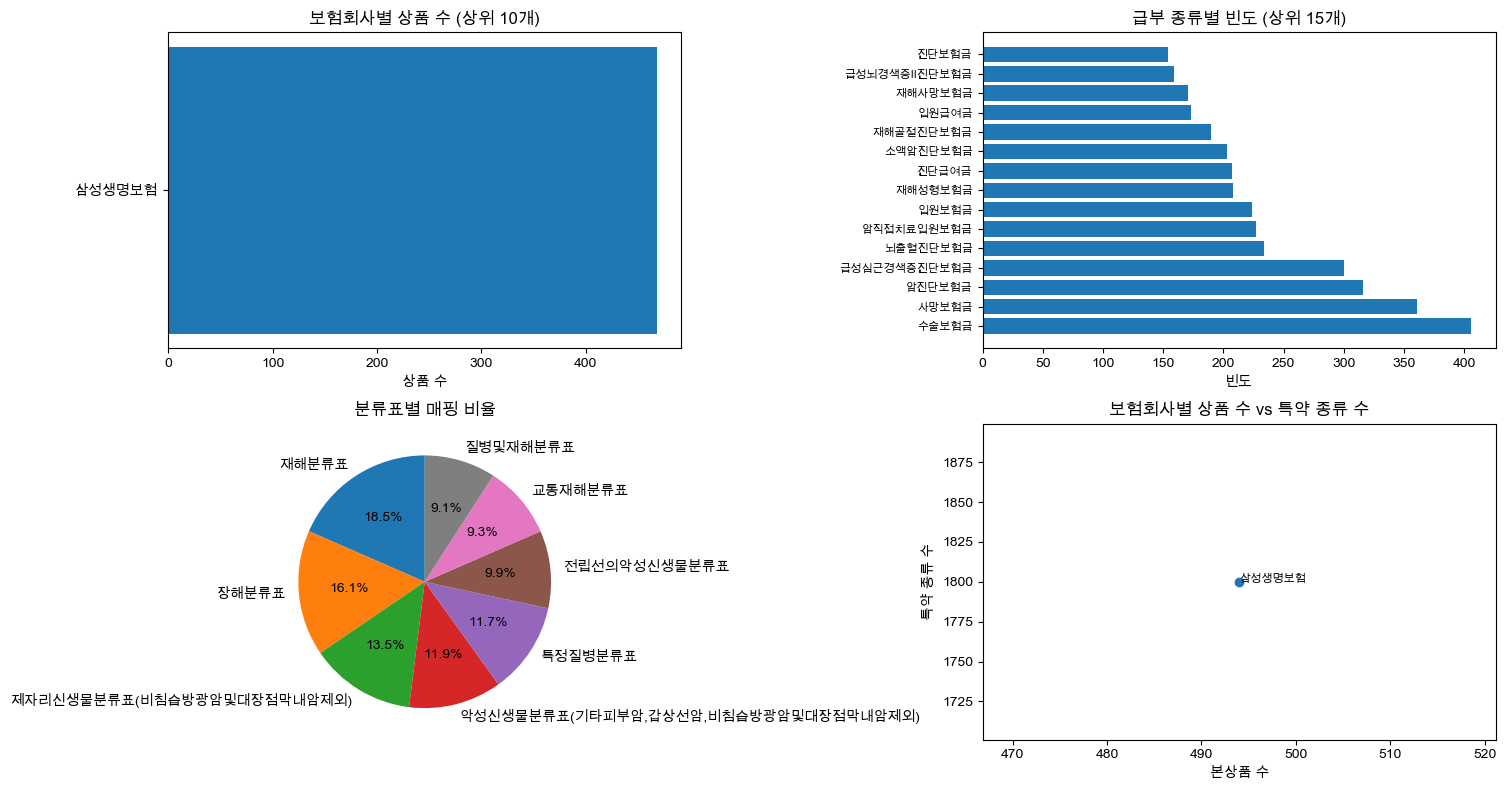

2025-09-14 19:23:36,684 - INFO - 데이터베이스 연결 종료
2025-09-14 19:23:36,688 - INFO - 데이터베이스 연결 완료
2025-09-14 19:23:36,698 - INFO - 데이터베이스 연결 종료
2025-09-14 19:23:36,698 - INFO - 데이터베이스 연결 완료
2025-09-14 19:23:36,705 - INFO - 데이터베이스 연결 종료
2025-09-14 19:23:36,705 - INFO - 데이터베이스 연결 완료
2025-09-14 19:23:36,715 - INFO - 데이터베이스 연결 종료


   시각화 완료: ssli_analysis.png 파일 저장

=== 추가 분석 예시 ===

'당뇨' 관련 상품 검색 결과: 132개
 보험회사명                              상품명                   급부명                                                                                                지급기준
삼성생명보험       삼성New올인원암보험(2204)(갱신형,무배당) 당뇨병(당화혈색소6.5%이상)진단보험금                                  피보험자가 이 특약의 보험기간 중 (당뇨병보장개시일) 이후에 “당뇨병(당화혈색소6.5%이상)”으로 진단확정 되었을 경우
삼성생명보험       삼성New올인원암보험(2207)(갱신형,무배당) 당뇨병(당화혈색소6.5%이상)진단보험금                                  피보험자가 이 특약의 보험기간 중 (당뇨병보장개시일) 이후에 “당뇨병(당화혈색소6.5%이상)”으로 진단확정 되었을 경우
삼성생명보험       삼성New올인원암보험(2301)(갱신형,무배당) 당뇨병(당화혈색소6.5%이상)진단보험금                                  피보험자가 이 특약의 보험기간 중 (당뇨병보장개시일) 이후에 “당뇨병(당화혈색소6.5%이상)”으로 진단확정 되었을 경우
삼성생명보험 삼성New올인원암보험2.0(갱신형,무배당)1종(일시지급형) 당뇨병(당화혈색소6.5%이상)진단보험금                                  피보험자가 이 특약의 보험기간 중 (당뇨병보장개시일) 이후에 “당뇨병(당화혈색소6.5%이상)”으로 진단확정 되었을 경우
삼성생명보험    삼성New원더풀종합보장보험(2204)(갱신형,무배당)         당뇨병성망막질환수술보험금       피보험자가 최초계약의 보장개시일 이후에 “당뇨병성망막질환”으로 진단이 확정되고, 

In [12]:
# 데이터 베이 만들기 SQLite #1 - 분석

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Optional
import logging

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = ['Arial Unicode MS', 'Malgun Gothic', 'AppleGothic']
plt.rcParams['axes.unicode_minus'] = False

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class SSLIAnalyzer:
    """SSLI 데이터베이스 분석 클래스"""
    
    def __init__(self, db_path: str = "ssli_insurance.db"):
        self.db_path = db_path
        self.conn = None
    
    def connect(self):
        """데이터베이스 연결"""
        self.conn = sqlite3.connect(self.db_path)
        logger.info("데이터베이스 연결 완료")
    
    def close(self):
        """데이터베이스 연결 종료"""
        if self.conn:
            self.conn.close()
            logger.info("데이터베이스 연결 종료")
    
    def get_company_summary(self) -> pd.DataFrame:
        """보험회사별 상품 및 급부 통계"""
        query = """
        SELECT 
            b.보험회사명,
            COUNT(DISTINCT b.상품명) as 상품수,
            COUNT(DISTINCT b.급부명) as 급부종류수,
            COUNT(*) as 총급부건수,
            COUNT(DISTINCT CASE WHEN c.분류코드 IS NOT NULL THEN b.상품명 END) as 분류표매핑상품수
        FROM bmt_data b
        LEFT JOIN cmt_data c ON b.보험회사명 = c.보험회사명 AND b.상품명 = c.상품명
        GROUP BY b.보험회사명
        ORDER BY 상품수 DESC
        """
        return pd.read_sql_query(query, self.conn)
    
    def get_benefit_analysis(self) -> pd.DataFrame:
        """급부 종류별 분석"""
        query = """
        SELECT 
            급부명,
            COUNT(*) as 빈도,
            COUNT(DISTINCT 보험회사명) as 제공회사수,
            COUNT(DISTINCT 상품명) as 제공상품수
        FROM bmt_data
        WHERE 급부명 IS NOT NULL AND 급부명 != ''
        GROUP BY 급부명
        HAVING 빈도 >= 10
        ORDER BY 빈도 DESC
        LIMIT 20
        """
        return pd.read_sql_query(query, self.conn)
    
    def get_cancer_products(self) -> pd.DataFrame:
        """암 관련 상품/급부 분석"""
        query = """
        SELECT 
            보험회사명,
            상품명,
            급부명,
            지급기준,
            지급내용
        FROM bmt_data
        WHERE (급부명 LIKE '%암%' OR 지급기준 LIKE '%암%' OR 지급내용 LIKE '%암%')
        AND 급부명 IS NOT NULL
        ORDER BY 보험회사명, 상품명
        """
        return pd.read_sql_query(query, self.conn)
    
    def get_death_products(self) -> pd.DataFrame:
        """사망 관련 상품/급부 분석"""
        query = """
        SELECT 
            보험회사명,
            상품명,
            급부명,
            지급기준,
            지급내용
        FROM bmt_data
        WHERE (급부명 LIKE '%사망%' OR 지급기준 LIKE '%사망%')
        AND 급부명 IS NOT NULL
        ORDER BY 보험회사명, 상품명
        """
        return pd.read_sql_query(query, self.conn)
    
    def get_classification_mapping(self) -> pd.DataFrame:
        """분류표 매핑 현황"""
        query = """
        SELECT 
            c.분류표명,
            COUNT(DISTINCT c.보험회사명) as 매핑회사수,
            COUNT(DISTINCT c.상품명) as 매핑상품수,
            COUNT(*) as 총매핑건수
        FROM cmt_data c
        WHERE c.분류표명 IS NOT NULL AND c.분류표명 != ''
        GROUP BY c.분류표명
        ORDER BY 총매핑건수 DESC
        """
        return pd.read_sql_query(query, self.conn)
    
    def get_product_coverage(self, company: str = None) -> pd.DataFrame:
        """상품별 보장 범위 분석"""
        where_clause = f"WHERE b.보험회사명 = '{company}'" if company else ""
        
        query = f"""
        SELECT 
            b.보험회사명,
            b.상품명,
            COUNT(DISTINCT b.급부명) as 급부종류수,
            COUNT(*) as 총급부건수,
            GROUP_CONCAT(DISTINCT b.급부명) as 급부목록
        FROM bmt_data b
        {where_clause}
        GROUP BY b.보험회사명, b.상품명
        HAVING 급부종류수 >= 5
        ORDER BY 급부종류수 DESC
        LIMIT 20
        """
        return pd.read_sql_query(query, self.conn)
    
    def search_products_by_benefit(self, benefit_keyword: str) -> pd.DataFrame:
        """특정 급부 키워드로 상품 검색"""
        query = """
        SELECT DISTINCT
            보험회사명,
            상품명,
            급부명,
            지급기준
        FROM bmt_data
        WHERE 급부명 LIKE ? OR 지급기준 LIKE ?
        ORDER BY 보험회사명, 상품명
        """
        return pd.read_sql_query(query, self.conn, params=[f'%{benefit_keyword}%', f'%{benefit_keyword}%'])
    
    def get_special_contract_analysis(self) -> pd.DataFrame:
        """특약 분석"""
        query = """
        SELECT 
            보험회사명,
            COUNT(DISTINCT 상품명) as 본상품수,
            COUNT(DISTINCT 특약명) as 특약종류수,
            COUNT(*) as 총특약건수
        FROM spt_data
        WHERE 특약명 IS NOT NULL AND 특약명 != ''
        GROUP BY 보험회사명
        ORDER BY 특약종류수 DESC
        """
        return pd.read_sql_query(query, self.conn)
    
    def create_visualizations(self):
        """데이터 시각화"""
        # 1. 보험회사별 상품 수
        company_summary = self.get_company_summary()
        
        plt.figure(figsize=(15, 8))
        plt.subplot(2, 2, 1)
        top_companies = company_summary.head(10)
        plt.barh(top_companies['보험회사명'], top_companies['상품수'])
        plt.title('보험회사별 상품 수 (상위 10개)')
        plt.xlabel('상품 수')
        
        # 2. 급부 종류별 빈도
        benefit_analysis = self.get_benefit_analysis()
        
        plt.subplot(2, 2, 2)
        top_benefits = benefit_analysis.head(15)
        plt.barh(range(len(top_benefits)), top_benefits['빈도'])
        plt.yticks(range(len(top_benefits)), top_benefits['급부명'], fontsize=8)
        plt.title('급부 종류별 빈도 (상위 15개)')
        plt.xlabel('빈도')
        
        # 3. 분류표 매핑 현황
        classification = self.get_classification_mapping()
        
        plt.subplot(2, 2, 3)
        plt.pie(classification['총매핑건수'].head(8), 
                labels=classification['분류표명'].head(8),
                autopct='%1.1f%%',
                startangle=90)
        plt.title('분류표별 매핑 비율')
        
        # 4. 특약 분석
        special_analysis = self.get_special_contract_analysis()
        
        plt.subplot(2, 2, 4)
        plt.scatter(special_analysis['본상품수'], special_analysis['특약종류수'])
        for i, company in enumerate(special_analysis['보험회사명'].head(10)):
            plt.annotate(company, 
                        (special_analysis['본상품수'].iloc[i], special_analysis['특약종류수'].iloc[i]),
                        fontsize=8)
        plt.xlabel('본상품 수')
        plt.ylabel('특약 종류 수')
        plt.title('보험회사별 상품 수 vs 특약 종류 수')
        
        plt.tight_layout()
        plt.savefig('ssli_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

def main():
    """메인 분석 실행"""
    analyzer = SSLIAnalyzer()
    
    try:
        analyzer.connect()
        
        print("=== SSLI 보험 데이터베이스 분석 ===\n")
        
        # 1. 보험회사별 요약
        print("1. 보험회사별 상품 및 급부 통계")
        company_summary = analyzer.get_company_summary()
        print(company_summary.head(10).to_string(index=False))
        print()
        
        # 2. 급부 종류별 분석
        print("2. 주요 급부 종류 (빈도순)")
        benefit_analysis = analyzer.get_benefit_analysis()
        print(benefit_analysis.head(15).to_string(index=False))
        print()
        
        # 3. 암 관련 상품 수
        cancer_products = analyzer.get_cancer_products()
        print(f"3. 암 관련 급부 제공 상품 수: {len(cancer_products)}개")
        print(f"   - 암 관련 급부를 제공하는 회사 수: {cancer_products['보험회사명'].nunique()}개")
        print()
        
        # 4. 사망 관련 상품 수
        death_products = analyzer.get_death_products()
        print(f"4. 사망 관련 급부 제공 상품 수: {len(death_products)}개")
        print(f"   - 사망 관련 급부를 제공하는 회사 수: {death_products['보험회사명'].nunique()}개")
        print()
        
        # 5. 분류표 매핑 현황
        print("5. 분류표 매핑 현황")
        classification = analyzer.get_classification_mapping()
        print(classification.to_string(index=False))
        print()
        
        # 6. 특약 분석
        print("6. 보험회사별 특약 현황")
        special_analysis = analyzer.get_special_contract_analysis()
        print(special_analysis.head(10).to_string(index=False))
        print()
        
        # 7. 보장 범위가 넓은 상품들
        print("7. 보장 범위가 넓은 상품 (급부 종류 5개 이상)")
        coverage = analyzer.get_product_coverage()
        for _, row in coverage.head(10).iterrows():
            print(f"   - {row['보험회사명']} / {row['상품명']} : {row['급부종류수']}개 급부")
        print()
        
        # 8. 시각화 생성
        print("8. 데이터 시각화 생성 중...")
        analyzer.create_visualizations()
        print("   시각화 완료: ssli_analysis.png 파일 저장")
        
    except Exception as e:
        logger.error(f"분석 중 오류 발생: {e}")
        
    finally:
        analyzer.close()

# 사용자 정의 검색 함수
def search_by_keyword(keyword: str):
    """키워드로 상품 검색"""
    analyzer = SSLIAnalyzer()
    analyzer.connect()
    
    try:
        results = analyzer.search_products_by_benefit(keyword)
        print(f"\n'{keyword}' 관련 상품 검색 결과: {len(results)}개")
        print(results.head(20).to_string(index=False))
        
    finally:
        analyzer.close()

# 특정 회사 분석 함수
def analyze_company(company_name: str):
    """특정 보험회사 분석"""
    analyzer = SSLIAnalyzer()
    analyzer.connect()
    
    try:
        coverage = analyzer.get_product_coverage(company_name)
        print(f"\n{company_name} 상품별 보장 범위:")
        print(coverage.to_string(index=False))
        
    finally:
        analyzer.close()

if __name__ == "__main__":
    main()
    
    # 추가 분석 예시
    print("\n=== 추가 분석 예시 ===")
    
    # 당뇨 관련 상품 검색
    search_by_keyword("당뇨")
    
    # 치매 관련 상품 검색
    search_by_keyword("치매")
    
    # 삼성생명보험 상품 분석
    analyze_company("삼성생명보험")

In [13]:
# 데이터 베이 만들기 SQLite #3 (품질검사)

import sqlite3
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Any
import logging
import re
from collections import Counter

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class SSLIDataQualityChecker:
    """SSLI 데이터베이스 품질 검토 클래스"""
    
    def __init__(self, db_path: str = "ssli_insurance.db"):
        self.db_path = db_path
        self.conn = None
        self.quality_report = {}
    
    def connect(self):
        """데이터베이스 연결"""
        self.conn = sqlite3.connect(self.db_path)
        logger.info("데이터베이스 연결 완료")
    
    def close(self):
        """데이터베이스 연결 종료"""
        if self.conn:
            self.conn.close()
            logger.info("데이터베이스 연결 종료")
    
    def check_basic_statistics(self) -> Dict[str, Any]:
        """기본 통계 정보 확인"""
        stats = {}
        
        tables = ['bmt_data', 'cmt_data', 'spt_data']
        
        for table in tables:
            query = f"SELECT COUNT(*) FROM {table}"
            row_count = pd.read_sql_query(query, self.conn).iloc[0, 0]
            
            # 컬럼 정보 가져오기
            query_columns = f"PRAGMA table_info({table})"
            columns_info = pd.read_sql_query(query_columns, self.conn)
            
            stats[table] = {
                'row_count': row_count,
                'column_count': len(columns_info),
                'columns': columns_info['name'].tolist()
            }
        
        self.quality_report['basic_stats'] = stats
        return stats
    
    def check_null_values(self) -> Dict[str, Any]:
        """NULL 값 및 빈 값 확인"""
        null_analysis = {}
        
        # BMT 테이블 NULL 체크
        bmt_query = """
        SELECT 
            COUNT(*) as total_rows,
            SUM(CASE WHEN 보험회사명 IS NULL OR 보험회사명 = '' THEN 1 ELSE 0 END) as null_company,
            SUM(CASE WHEN 상품명 IS NULL OR 상품명 = '' THEN 1 ELSE 0 END) as null_product,
            SUM(CASE WHEN 특약명 IS NULL OR 특약명 = '' THEN 1 ELSE 0 END) as null_special_contract,
            SUM(CASE WHEN 급부명 IS NULL OR 급부명 = '' THEN 1 ELSE 0 END) as null_benefit,
            SUM(CASE WHEN 지급기준 IS NULL OR 지급기준 = '' THEN 1 ELSE 0 END) as null_payment_criteria,
            SUM(CASE WHEN 지급내용 IS NULL OR 지급내용 = '' THEN 1 ELSE 0 END) as null_payment_content,
            SUM(CASE WHEN 기타사항 IS NULL OR 기타사항 = '' THEN 1 ELSE 0 END) as null_other,
            SUM(CASE WHEN 대상 IS NULL OR 대상 = '' THEN 1 ELSE 0 END) as null_target
        FROM bmt_data
        """
        bmt_nulls = pd.read_sql_query(bmt_query, self.conn).iloc[0].to_dict()
        
        # CMT 테이블 NULL 체크
        cmt_query = """
        SELECT 
            COUNT(*) as total_rows,
            SUM(CASE WHEN 보험회사명 IS NULL OR 보험회사명 = '' THEN 1 ELSE 0 END) as null_company,
            SUM(CASE WHEN 상품명 IS NULL OR 상품명 = '' THEN 1 ELSE 0 END) as null_product,
            SUM(CASE WHEN 분류표명 IS NULL OR 분류표명 = '' THEN 1 ELSE 0 END) as null_classification,
            SUM(CASE WHEN 분류코드 IS NULL OR 분류코드 = '' THEN 1 ELSE 0 END) as null_code
        FROM cmt_data
        """
        cmt_nulls = pd.read_sql_query(cmt_query, self.conn).iloc[0].to_dict()
        
        # SPT 테이블 NULL 체크
        spt_query = """
        SELECT 
            COUNT(*) as total_rows,
            SUM(CASE WHEN 보험회사명 IS NULL OR 보험회사명 = '' THEN 1 ELSE 0 END) as null_company,
            SUM(CASE WHEN 상품명 IS NULL OR 상품명 = '' THEN 1 ELSE 0 END) as null_product,
            SUM(CASE WHEN 특약명 IS NULL OR 특약명 = '' THEN 1 ELSE 0 END) as null_special_contract
        FROM spt_data
        """
        spt_nulls = pd.read_sql_query(spt_query, self.conn).iloc[0].to_dict()
        
        null_analysis = {
            'bmt_data': bmt_nulls,
            'cmt_data': cmt_nulls,
            'spt_data': spt_nulls
        }
        
        self.quality_report['null_analysis'] = null_analysis
        return null_analysis
    
    def check_duplicates(self) -> Dict[str, Any]:
        """중복 데이터 확인"""
        duplicate_analysis = {}
        
        # BMT 완전 중복 체크
        bmt_duplicate_query = """
        SELECT COUNT(*) as duplicate_rows FROM (
            SELECT 보험회사명, 상품명, 특약명, 급부명, 지급기준, 지급내용, 기타사항, 대상, COUNT(*) as cnt
            FROM bmt_data
            GROUP BY 보험회사명, 상품명, 특약명, 급부명, 지급기준, 지급내용, 기타사항, 대상
            HAVING cnt > 1
        )
        """
        bmt_duplicates = pd.read_sql_query(bmt_duplicate_query, self.conn).iloc[0, 0]
        
        # CMT 중복 체크
        cmt_duplicate_query = """
        SELECT COUNT(*) as duplicate_rows FROM (
            SELECT 보험회사명, 상품명, 분류표명, 분류코드, COUNT(*) as cnt
            FROM cmt_data
            GROUP BY 보험회사명, 상품명, 분류표명, 분류코드
            HAVING cnt > 1
        )
        """
        cmt_duplicates = pd.read_sql_query(cmt_duplicate_query, self.conn).iloc[0, 0]
        
        # SPT 중복 체크
        spt_duplicate_query = """
        SELECT COUNT(*) as duplicate_rows FROM (
            SELECT 보험회사명, 상품명, 특약명, COUNT(*) as cnt
            FROM spt_data
            GROUP BY 보험회사명, 상품명, 특약명
            HAVING cnt > 1
        )
        """
        spt_duplicates = pd.read_sql_query(spt_duplicate_query, self.conn).iloc[0, 0]
        
        duplicate_analysis = {
            'bmt_duplicates': bmt_duplicates,
            'cmt_duplicates': cmt_duplicates,
            'spt_duplicates': spt_duplicates
        }
        
        self.quality_report['duplicate_analysis'] = duplicate_analysis
        return duplicate_analysis
    
    def check_data_consistency(self) -> Dict[str, Any]:
        """데이터 일관성 확인"""
        consistency_issues = {}
        
        # 1. BMT와 SPT 간 상품명 매칭 확인
        bmt_products_query = "SELECT DISTINCT 보험회사명, 상품명 FROM bmt_data"
        spt_products_query = "SELECT DISTINCT 보험회사명, 상품명 FROM spt_data"
        
        bmt_products = set(pd.read_sql_query(bmt_products_query, self.conn).apply(lambda x: f"{x[0]}|{x[1]}", axis=1))
        spt_products = set(pd.read_sql_query(spt_products_query, self.conn).apply(lambda x: f"{x[0]}|{x[1]}", axis=1))
        
        bmt_only = bmt_products - spt_products
        spt_only = spt_products - bmt_products
        common_products = bmt_products & spt_products
        
        consistency_issues['bmt_spt_matching'] = {
            'bmt_only_products': len(bmt_only),
            'spt_only_products': len(spt_only),
            'common_products': len(common_products),
            'bmt_total': len(bmt_products),
            'spt_total': len(spt_products),
            'match_ratio': len(common_products) / len(bmt_products | spt_products) if (bmt_products | spt_products) else 0
        }
        
        # 2. BMT와 CMT 간 상품명 매칭 확인
        cmt_products_query = "SELECT DISTINCT 보험회사명, 상품명 FROM cmt_data"
        cmt_products = set(pd.read_sql_query(cmt_products_query, self.conn).apply(lambda x: f"{x[0]}|{x[1]}", axis=1))
        
        bmt_cmt_common = bmt_products & cmt_products
        cmt_only = cmt_products - bmt_products
        
        consistency_issues['bmt_cmt_matching'] = {
            'cmt_only_products': len(cmt_only),
            'common_products': len(bmt_cmt_common),
            'cmt_total': len(cmt_products),
            'match_ratio': len(bmt_cmt_common) / len(cmt_products) if cmt_products else 0
        }
        
        self.quality_report['consistency_issues'] = consistency_issues
        return consistency_issues
    
    def check_data_format_issues(self) -> Dict[str, Any]:
        """데이터 형식 문제 확인"""
        format_issues = {}
        
        # 1. 보험회사명 표준화 확인
        company_query = """
        SELECT 
            '보험회사명' as field,
            보험회사명 as value,
            COUNT(*) as frequency,
            'BMT' as source
        FROM bmt_data
        GROUP BY 보험회사명
        UNION ALL
        SELECT 
            '보험회사명' as field,
            보험회사명 as value,
            COUNT(*) as frequency,
            'CMT' as source
        FROM cmt_data
        GROUP BY 보험회사명
        UNION ALL
        SELECT 
            '보험회사명' as field,
            보험회사명 as value,
            COUNT(*) as frequency,
            'SPT' as source
        FROM spt_data
        GROUP BY 보험회사명
        ORDER BY value, source
        """
        company_data = pd.read_sql_query(company_query, self.conn)
        
        # 보험회사명 일관성 분석
        company_variations = {}
        for company in company_data['value'].unique():
            if company and company.strip():
                variations = company_data[company_data['value'] == company]['source'].tolist()
                company_variations[company] = variations
        
        format_issues['company_name_consistency'] = {
            'total_unique_companies': len(company_variations),
            'companies_in_all_tables': len([c for c, v in company_variations.items() if len(set(v)) == 3]),
            'companies_variations': company_variations
        }
        
        # 2. 특수문자 및 길이 확인
        length_query = """
        SELECT 
            'BMT_급부명' as field,
            MIN(LENGTH(급부명)) as min_length,
            MAX(LENGTH(급부명)) as max_length,
            AVG(LENGTH(급부명)) as avg_length
        FROM bmt_data WHERE 급부명 IS NOT NULL AND 급부명 != ''
        UNION ALL
        SELECT 
            'BMT_지급기준' as field,
            MIN(LENGTH(지급기준)) as min_length,
            MAX(LENGTH(지급기준)) as max_length,
            AVG(LENGTH(지급기준)) as avg_length
        FROM bmt_data WHERE 지급기준 IS NOT NULL AND 지급기준 != ''
        """
        length_analysis = pd.read_sql_query(length_query, self.conn)
        format_issues['field_length_analysis'] = length_analysis.to_dict('records')
        
        self.quality_report['format_issues'] = format_issues
        return format_issues
    
    def check_business_logic_issues(self) -> Dict[str, Any]:
        """비즈니스 로직 관련 이슈 확인"""
        business_issues = {}
        
        # 1. 급부명과 지급기준의 논리적 일관성 확인
        inconsistency_query = """
        SELECT 
            급부명,
            지급기준,
            COUNT(*) as frequency
        FROM bmt_data
        WHERE 급부명 LIKE '%사망%' AND 지급기준 NOT LIKE '%사망%'
        GROUP BY 급부명, 지급기준
        ORDER BY frequency DESC
        LIMIT 10
        """
        death_inconsistency = pd.read_sql_query(inconsistency_query, self.conn)
        
        # 2. 암 관련 급부 일관성 확인
        cancer_inconsistency_query = """
        SELECT 
            급부명,
            지급기준,
            COUNT(*) as frequency
        FROM bmt_data
        WHERE 급부명 LIKE '%암%' AND 지급기준 NOT LIKE '%암%'
        GROUP BY 급부명, 지급기준
        ORDER BY frequency DESC
        LIMIT 10
        """
        cancer_inconsistency = pd.read_sql_query(cancer_inconsistency_query, self.conn)
        
        business_issues['logic_inconsistencies'] = {
            'death_benefit_inconsistencies': len(death_inconsistency),
            'cancer_benefit_inconsistencies': len(cancer_inconsistency)
        }
        
        # 3. 분류코드 형식 확인
        classification_format_query = """
        SELECT 
            분류코드,
            LENGTH(분류코드) as code_length,
            COUNT(*) as frequency
        FROM cmt_data
        WHERE 분류코드 IS NOT NULL AND 분류코드 != ''
        GROUP BY 분류코드, LENGTH(분류코드)
        ORDER BY frequency DESC
        """
        classification_format = pd.read_sql_query(classification_format_query, self.conn)
        
        business_issues['classification_code_formats'] = {
            'unique_code_formats': len(classification_format),
            'most_common_length': classification_format.iloc[0]['code_length'] if len(classification_format) > 0 else None
        }
        
        self.quality_report['business_issues'] = business_issues
        return business_issues
    
    def check_data_completeness(self) -> Dict[str, Any]:
        """데이터 완성도 확인"""
        completeness = {}
        
        # 핵심 필드 완성도 확인
        bmt_completeness_query = """
        SELECT 
            ROUND(COUNT(CASE WHEN 보험회사명 IS NOT NULL AND 보험회사명 != '' THEN 1 END) * 100.0 / COUNT(*), 2) as 보험회사명_완성도,
            ROUND(COUNT(CASE WHEN 상품명 IS NOT NULL AND 상품명 != '' THEN 1 END) * 100.0 / COUNT(*), 2) as 상품명_완성도,
            ROUND(COUNT(CASE WHEN 급부명 IS NOT NULL AND 급부명 != '' THEN 1 END) * 100.0 / COUNT(*), 2) as 급부명_완성도,
            ROUND(COUNT(CASE WHEN 지급기준 IS NOT NULL AND 지급기준 != '' THEN 1 END) * 100.0 / COUNT(*), 2) as 지급기준_완성도,
            ROUND(COUNT(CASE WHEN 지급내용 IS NOT NULL AND 지급내용 != '' THEN 1 END) * 100.0 / COUNT(*), 2) as 지급내용_완성도
        FROM bmt_data
        """
        bmt_completeness = pd.read_sql_query(bmt_completeness_query, self.conn).iloc[0].to_dict()
        
        completeness['bmt_completeness'] = bmt_completeness
        
        self.quality_report['completeness'] = completeness
        return completeness
    
    def generate_quality_report(self) -> Dict[str, Any]:
        """전체 품질 보고서 생성"""
        print("=== SSLI 데이터베이스 품질 검토 보고서 ===\n")
        
        # 1. 기본 통계
        print("1. 기본 통계 정보")
        basic_stats = self.check_basic_statistics()
        for table, stats in basic_stats.items():
            print(f"   {table}: {stats['row_count']:,}개 행, {stats['column_count']}개 컬럼")
        print()
        
        # 2. NULL 값 분석
        print("2. NULL/빈 값 분석")
        null_analysis = self.check_null_values()
        for table, nulls in null_analysis.items():
            total_rows = nulls['total_rows']
            print(f"   {table} (총 {total_rows:,}개 행):")
            for field, null_count in nulls.items():
                if field != 'total_rows' and null_count > 0:
                    percentage = (null_count / total_rows) * 100
                    print(f"     - {field}: {null_count:,}개 ({percentage:.2f}%)")
        print()
        
        # 3. 중복 데이터 분석
        print("3. 중복 데이터 분석")
        duplicate_analysis = self.check_duplicates()
        for table, count in duplicate_analysis.items():
            print(f"   {table}: {count}개의 중복 그룹")
        print()
        
        # 4. 데이터 일관성 분석
        print("4. 데이터 일관성 분석")
        consistency = self.check_data_consistency()
        
        bmt_spt = consistency['bmt_spt_matching']
        print(f"   BMT-SPT 상품 매칭:")
        print(f"     - 공통 상품: {bmt_spt['common_products']:,}개")
        print(f"     - BMT 전용: {bmt_spt['bmt_only_products']:,}개")
        print(f"     - SPT 전용: {bmt_spt['spt_only_products']:,}개")
        print(f"     - 매칭률: {bmt_spt['match_ratio']:.2%}")
        
        bmt_cmt = consistency['bmt_cmt_matching']
        print(f"   BMT-CMT 상품 매칭:")
        print(f"     - 공통 상품: {bmt_cmt['common_products']:,}개")
        print(f"     - CMT 전용: {bmt_cmt['cmt_only_products']:,}개")
        print(f"     - 매칭률: {bmt_cmt['match_ratio']:.2%}")
        print()
        
        # 5. 데이터 형식 분석
        print("5. 데이터 형식 분석")
        format_issues = self.check_data_format_issues()
        
        company_consistency = format_issues['company_name_consistency']
        print(f"   보험회사명 일관성:")
        print(f"     - 총 고유 회사 수: {company_consistency['total_unique_companies']}개")
        print(f"     - 3개 테이블 모두 존재: {company_consistency['companies_in_all_tables']}개")
        print()
        
        # 6. 비즈니스 로직 분석
        print("6. 비즈니스 로직 분석")
        business_issues = self.check_business_logic_issues()
        logic_issues = business_issues['logic_inconsistencies']
        print(f"   급부명-지급기준 불일치:")
        print(f"     - 사망 관련 불일치: {logic_issues['death_benefit_inconsistencies']}건")
        print(f"     - 암 관련 불일치: {logic_issues['cancer_benefit_inconsistencies']}건")
        print()
        
        # 7. 데이터 완성도
        print("7. 핵심 필드 완성도 (BMT 테이블)")
        completeness = self.check_data_completeness()
        bmt_comp = completeness['bmt_completeness']
        for field, percentage in bmt_comp.items():
            print(f"   {field}: {percentage}%")
        print()
        
        # 8. 전체 품질 점수 계산
        quality_score = self._calculate_quality_score()
        print(f"8. 전체 데이터 품질 점수: {quality_score}/100")
        self._provide_recommendations(quality_score)
        
        return self.quality_report
    
    def _calculate_quality_score(self) -> int:
        """데이터 품질 점수 계산 (100점 만점)"""
        score = 100
        
        # 완성도 기반 감점
        if 'completeness' in self.quality_report:
            bmt_comp = self.quality_report['completeness']['bmt_completeness']
            avg_completeness = sum(bmt_comp.values()) / len(bmt_comp)
            score -= (100 - avg_completeness) * 0.3
        
        # 중복 데이터 기반 감점
        if 'duplicate_analysis' in self.quality_report:
            duplicates = sum(self.quality_report['duplicate_analysis'].values())
            if duplicates > 0:
                score -= min(20, duplicates * 0.1)
        
        # 일관성 기반 가점/감점
        if 'consistency_issues' in self.quality_report:
            match_ratio = self.quality_report['consistency_issues']['bmt_spt_matching']['match_ratio']
            score += (match_ratio - 0.5) * 20
        
        return max(0, int(score))
    
    def _provide_recommendations(self, quality_score: int):
        """품질 개선 권장사항 제공"""
        print("\n=== 품질 개선 권장사항 ===")
        
        if quality_score >= 90:
            print("✅ 우수한 데이터 품질입니다.")
        elif quality_score >= 80:
            print("⚠️ 양호한 데이터 품질이지만 일부 개선이 필요합니다.")
        elif quality_score >= 70:
            print("🔧 보통 수준의 데이터 품질입니다. 개선이 권장됩니다.")
        else:
            print("❌ 데이터 품질이 낮습니다. 즉시 개선이 필요합니다.")
        
        print("\n권장사항:")
        
        # NULL 값 관련 권장사항
        if 'null_analysis' in self.quality_report:
            null_issues = False
            for table, nulls in self.quality_report['null_analysis'].items():
                total = nulls['total_rows']
                for field, count in nulls.items():
                    if field != 'total_rows' and count / total > 0.1:  # 10% 이상 NULL
                        null_issues = True
                        break
            
            if null_issues:
                print("1. 핵심 필드의 NULL/빈 값을 채우거나 기본값을 설정하세요.")
        
        # 중복 데이터 관련 권장사항
        if 'duplicate_analysis' in self.quality_report:
            duplicates = sum(self.quality_report['duplicate_analysis'].values())
            if duplicates > 0:
                print("2. 중복 데이터를 제거하거나 통합하세요.")
        
        # 일관성 관련 권장사항
        if 'consistency_issues' in self.quality_report:
            match_ratio = self.quality_report['consistency_issues']['bmt_spt_matching']['match_ratio']
            if match_ratio < 0.8:
                print("3. 테이블 간 상품명 매칭을 개선하세요.")
        
        print("4. 정기적인 데이터 품질 모니터링을 설정하세요.")
        print("5. 데이터 입력 시 검증 규칙을 적용하세요.")

def main():
    """메인 실행 함수"""
    checker = SSLIDataQualityChecker()
    
    try:
        checker.connect()
        quality_report = checker.generate_quality_report()
        
        # 상세 분석 결과를 파일로 저장
        import json
        with open('ssli_quality_report.json', 'w', encoding='utf-8') as f:
            json.dump(quality_report, f, ensure_ascii=False, indent=2, default=str)
        
        print(f"\n상세 분석 결과가 'ssli_quality_report.json'에 저장되었습니다.")
        
    except Exception as e:
        logger.error(f"품질 검토 중 오류 발생: {e}")
        
    finally:
        checker.close()

if __name__ == "__main__":
    main()

2025-09-14 19:27:05,702 - INFO - 데이터베이스 연결 완료
/var/folders/mk/0bj8n18d40s6kclsg8cxnwp80000gn/T/ipykernel_8136/3948866475.py:160: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bmt_products = set(pd.read_sql_query(bmt_products_query, self.conn).apply(lambda x: f"{x[0]}|{x[1]}", axis=1))
/var/folders/mk/0bj8n18d40s6kclsg8cxnwp80000gn/T/ipykernel_8136/3948866475.py:161: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spt_products = set(pd.read_sql_query(spt_products_query, self.conn).apply(lambda x: f"{x[0]}|{x[1]}", axis=1))
/var/folders/mk/0bj8n18d40s6kclsg8cxnwp80000gn/T/ipykernel_8136/3948866475.py:178: FutureWarning: 

=== SSLI 데이터베이스 품질 검토 보고서 ===

1. 기본 통계 정보
   bmt_data: 15,084개 행, 11개 컬럼
   cmt_data: 1,773개 행, 7개 컬럼
   spt_data: 10,453개 행, 6개 컬럼

2. NULL/빈 값 분석
   bmt_data (총 15,084개 행):
   cmt_data (총 1,773개 행):
   spt_data (총 10,453개 행):

3. 중복 데이터 분석
   bmt_duplicates: 3개의 중복 그룹
   cmt_duplicates: 0개의 중복 그룹
   spt_duplicates: 0개의 중복 그룹

4. 데이터 일관성 분석
   BMT-SPT 상품 매칭:
     - 공통 상품: 468개
     - BMT 전용: 0개
     - SPT 전용: 26개
     - 매칭률: 94.74%
   BMT-CMT 상품 매칭:
     - 공통 상품: 101개
     - CMT 전용: 0개
     - 매칭률: 100.00%

5. 데이터 형식 분석
   보험회사명 일관성:
     - 총 고유 회사 수: 1개
     - 3개 테이블 모두 존재: 1개

6. 비즈니스 로직 분석
   급부명-지급기준 불일치:
     - 사망 관련 불일치: 10건
     - 암 관련 불일치: 3건

7. 핵심 필드 완성도 (BMT 테이블)
   보험회사명_완성도: 100.0%
   상품명_완성도: 100.0%
   급부명_완성도: 100.0%
   지급기준_완성도: 100.0%
   지급내용_완성도: 100.0%

8. 전체 데이터 품질 점수: 108/100

=== 품질 개선 권장사항 ===
✅ 우수한 데이터 품질입니다.

권장사항:
2. 중복 데이터를 제거하거나 통합하세요.
4. 정기적인 데이터 품질 모니터링을 설정하세요.
5. 데이터 입력 시 검증 규칙을 적용하세요.

상세 분석 결과가 'ssli_quality_report.json'에 저장되었습니다.
